In [ ]:
# mount the data from google drive
from google.colab import drive
from google.colab import files
drive.mount("/content/drive")

# navigate to the project folder
%cd drive/MyDrive/projects/CVPR

Mounted at /content/drive
/content/drive/MyDrive/projects/CVPR


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from typing import Tuple, List, Union, Optional
import os
import pandas as pd
import glob
from scipy.stats import zscore
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

coco = pd.read_csv('combined_output3.csv')
oif_aes = pd.read_csv('values_aesthetic.csv')
oif_mem = pd.read_csv('values_memorize.csv')
oif = pd.concat([oif_aes, oif_mem])


In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error

def regression_results_summary(model, X, y, y_pred):
    """
    Generate a summary table for linear regression results.

    Args:
    model: The fitted regression model (e.g., LinearRegression or OLS results).
    X: The input features used for model fitting (independent variables).
    y: The actual target values (dependent variable).
    y_pred: The predicted target values.

    Returns:
    pandas.DataFrame: A summary table with regression statistics.
    """

    # Number of observations
    n_observations = len(X)

    # R-squared value
    r_squared = model.score(X, y)

    # Adjusted R-squared value
    n_features = X.shape[1]  # Number of features
    adjusted_r_squared = 1 - (1 - r_squared) * (n_observations - 1) / (n_observations - n_features - 1)

    # F-statistic and p-value (overall model)
    if hasattr(model, 'fvalue'):  # For statsmodels OLS result
        f_statistic = model.fvalue
        p_value_overall = model.f_pvalue
    else:  # For sklearn LinearRegression
        # F-statistic calculation based on R-squared
        ss_total = ((y - y.mean())**2).sum()
        ss_residual = ((y - y_pred)**2).sum()
        f_statistic = (r_squared / (n_features)) / ((1 - r_squared) / (n_observations - n_features - 1))
        p_value_overall = 1 - f_statistic  # This is a simplification; sklearn doesn't provide exact p-value for F-statistic.

    # Mean Absolute Error
    mae = mean_absolute_error(y, y_pred)

    # Create summary table
    summary_dict = {
        'Number of Observations': [n_observations],
        'R-squared': [r_squared],
        'Adjusted R-squared': [adjusted_r_squared],
        'F-statistic': [f_statistic],
        'p-value (Overall Model)': [p_value_overall],
        'Mean Absolute Error': [mae]
    }

    # Convert to DataFrame
    summary_table = pd.DataFrame(summary_dict)

    return summary_table

# Example usage:
# Assuming `model` is your fitted model, and `X`, `y`, and `y_pred` are your input data and predictions.
summary_table = regression_results_summary(model, X, y, y_pred)
print(summary_table)


NameError: name 'model' is not defined

In [ ]:
oif = oif_mem
oif = oif[oif['size']> 10]
oif_mem['sum'] = oif_mem['sum'] + oif_aes['sum']
values = oif

values['log_size'] = np.log1p(values['size'])
values['log_sum'] = np.log1p(values['sum'])
values['log_depth'] = np.log1p(values['depth_center'])
values['z_ecc'] = zscore(values['ecc'])
values['z_dg'] = zscore(values['dg_center'])
mod = smf.ols(formula='log_sum ~ log_depth + z_ecc + log_size + z_dg', data=values)
res = mod.fit()
print(res.summary())

# Fit the model and get predictions
X = values[['z_ecc', 'log_size', 'log_depth', 'z_dg']]
y = values['log_sum']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Calculate residuals
residuals = y - y_pred
values['log_pred'] = y_pred
values['pred'] = np.expm1(values['log_pred'])
values['log_abs_residual'] = np.abs(values['log_sum'] - values['log_pred'])
values['log_residual'] = values['log_sum'] - values['log_pred']
values['sum_diff'] = values['sum'] - values['pred']
values['abs_diff'] = np.abs(values['sum_diff'])

# Inverse transformation using np.expm1() to reverse the log transformation
y_exp = np.expm1(y)  # Reverse log-transformation on actual values
y_pred_exp = np.expm1(y_pred)  # Reverse log-transformation on predicted values

# Calculate residuals
values['log_pred'] = y_pred
values['pred'] = y_pred_exp  # Use inverse transformed predictions
values['log_abs_residual'] = np.abs(y - y_pred)
values['log_residual'] = y - y_pred
values['sum_diff'] = values['sum'] - values['pred']
values['abs_diff'] = np.abs(values['sum_diff'])

# Calculate Mean Absolute Error (MAE) for the entire dataset using expm1-transformed values
mae = mean_absolute_error(y_exp, y_pred_exp)

# Print overall MAE
print(f"Mean Absolute Error (overall) using expm1: {mae}")

# Calculate MAE by scene (image) using expm1-transformed values
mae_by_scene = values.groupby('image')['abs_diff'].mean()

# Calculate average MAE across scenes (images)
average_mae_across_scenes = mae_by_scene.mean()

# Print average MAE across scenes
print(f"\nAverage Mean Absolute Error across scenes (images) using expm1: {average_mae_across_scenes}")

                            OLS Regression Results                            
Dep. Variable:                log_sum   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.805
Method:                 Least Squares   F-statistic:                     2565.
Date:                Mon, 01 Sep 2025   Prob (F-statistic):               0.00
Time:                        21:46:36   Log-Likelihood:                -2474.9
No. Observations:                2493   AIC:                             4960.
Df Residuals:                    2488   BIC:                             4989.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.6791      0.073    -50.351      0.0

/tmp/ipython-input-1601954734.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  values['log_size'] = np.log1p(values['size'])
/tmp/ipython-input-1601954734.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  values['log_sum'] = np.log1p(values['sum'])
/tmp/ipython-input-1601954734.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

In [ ]:
values = coco

values['log_size'] = np.log1p(values['size'])
values['log_sum'] = np.log1p(values['sum'])
values['log_depth'] = np.log1p(values['depth_center'])
values['z_ecc'] = zscore(values['ecc'])
values['z_dg'] = zscore(values['dg_center'])
mod = smf.ols(formula='log_sum ~ log_depth + z_ecc + log_size + z_dg', data=values)
res = mod.fit()
print(res.summary())

# Fit the model and get predictions
X = values[['z_ecc', 'log_size', 'log_depth', 'z_dg']]
y = values['log_sum']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Calculate residuals
residuals = y - y_pred
values['pred'] = y_pred
values['pred_sum'] = np.expm1(values['pred'])
values['residual'] = np.abs(values['log_sum'] - values['pred'])
values['sum_diff'] = values['sum'] - values['pred_sum']
values['abs_diff'] = np.abs(values['sum_diff'])
image_values = values.groupby(['image'])['abs_diff'].sum().reset_index()
coco_best_images = image_values.sort_values(by='abs_diff')[:15]
coco_worst_images = image_values.sort_values(by='abs_diff')[-15:]

                            OLS Regression Results                            
Dep. Variable:                log_sum   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.665
Method:                 Least Squares   F-statistic:                 1.543e+04
Date:                Mon, 01 Sep 2025   Prob (F-statistic):               0.00
Time:                        21:51:09   Log-Likelihood:                -34331.
No. Observations:               31138   AIC:                         6.867e+04
Df Residuals:                   31133   BIC:                         6.871e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.7519      0.029   -128.620      0.0

In [ ]:
coco_best_images

,image,abs_diff
2215,573448,2.086130
732,191540,3.587193
469,118227,3.765954
1596,418213,4.371583
452,114173,4.494236
1770,464602,4.502500
1736,453111,4.676421
2110,547156,5.049324
1058,277427,5.390595
496,126311,5.921269


In [ ]:
coco = coco[['image', 'label', 'sum', 'size', 'ecc', 'dg_center', 'depth_center']].copy()
coco['ds'] = 'coco'
oif = oif[['image', 'label', 'sum', 'size', 'ecc', 'dg_center', 'depth_center']].copy()
oif['ds'] = 'oif'
values = pd.concat([coco, oif])

values['log_size'] = np.log1p(values['size'])
values['log_sum'] = np.log1p(values['sum'])
values['log_depth'] = np.log1p(values['depth_center'])
values['z_ecc'] = zscore(values['ecc'])
values['z_dg'] = zscore(values['dg_center'])
mod = smf.ols(formula='log_sum ~ log_depth + z_ecc + log_size + z_dg ', data=values)
res = mod.fit()
print(res.summary())

# Fit the model and get predictions
X = values[['z_ecc', 'log_size', 'log_depth', 'z_dg']]
y = values['log_sum']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Calculate residuals
residuals = y - y_pred
values['log_pred'] = y_pred
values['pred'] = np.expm1(values['log_pred'])
values['log_abs_residual'] = np.abs(values['log_sum'] - values['log_pred'])
values['log_residual'] = values['log_sum'] - values['log_pred']
values['sum_diff'] = values['sum'] - values['pred']
values['abs_diff'] = np.abs(values['sum_diff'])


                            OLS Regression Results                            
Dep. Variable:                log_sum   R-squared:                       0.542
Model:                            OLS   Adj. R-squared:                  0.542
Method:                 Least Squares   F-statistic:                     9932.
Date:                Mon, 01 Sep 2025   Prob (F-statistic):               0.00
Time:                        21:48:10   Log-Likelihood:                -44728.
No. Observations:               33631   AIC:                         8.947e+04
Df Residuals:                   33626   BIC:                         8.951e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.0491      0.034    -90.094      0.0

In [ ]:
coco = coco[['image', 'label', 'sum', 'size', 'ecc', 'dg_center', 'depth_center']].copy()
coco['ds'] = 'coco'
oif = oif[['image', 'label', 'sum', 'size', 'ecc', 'dg_center', 'depth_center']].copy()
oif['ds'] = 'oif'
values = pd.concat([coco, oif])

values['log_size'] = np.log1p(values['size'])
values['log_sum'] = np.log1p(values['sum'])
values['log_depth'] = np.log1p(values['depth_center'])
values['z_ecc'] = zscore(values['ecc'])
values['z_dg'] = zscore(values['dg_center'])
mod = smf.ols(formula='log_sum ~ log_depth + z_ecc + log_size + z_dg + ds ', data=values)
res = mod.fit()
print(res.summary())

# Fit the model and get predictions
X = values[['z_ecc', 'log_size', 'log_depth', 'z_dg', 'ds']]
y = values['log_sum']
model1 = LinearRegression()
model1.fit(X, y)
y_pred = model1.predict(X)

# Calculate residuals
residuals = y - y_pred
values['log_pred'] = y_pred
values['pred'] = np.expm1(values['log_pred'])
values['log_abs_residual'] = np.abs(values['log_sum'] - values['log_pred'])
values['log_residual'] = values['log_sum'] - values['log_pred']
values['sum_diff'] = values['sum'] - values['pred']
values['abs_diff'] = np.abs(values['sum_diff'])

mae = mean_absolute_error(y, y_pred)

print(mae)

                            OLS Regression Results                            
Dep. Variable:                log_sum   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.706
Method:                 Least Squares   F-statistic:                 1.612e+04
Date:                Mon, 01 Sep 2025   Prob (F-statistic):               0.00
Time:                        21:48:15   Log-Likelihood:                -37284.
No. Observations:               33631   AIC:                         7.458e+04
Df Residuals:                   33625   BIC:                         7.463e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.9650      0.028   -141.926      0.0

ValueError: could not convert string to float: 'coco'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Assuming 'values' is your DataFrame
# One-hot encode the 'ds' variable
values_encoded = pd.get_dummies(values, columns=['ds'], drop_first=True)  # drop_first to avoid multicollinearity

# Define X and y for model fitting
X = values_encoded[['z_ecc', 'log_size', 'log_depth', 'z_dg', 'ds_oif']]  # Assuming 'ds_oif' is the encoded column
y = values['log_sum']

# Fit the model and get predictions
model1 = LinearRegression()
model1.fit(X, y)
y_pred = model1.predict(X)

# Inverse transformation using np.expm1() to reverse the log transformation
y_exp = np.expm1(y)  # Reverse log-transformation on actual values
y_pred_exp = np.expm1(y_pred)  # Reverse log-transformation on predicted values

# Calculate residuals
values['log_pred'] = y_pred
values['pred'] = y_pred_exp  # Use inverse transformed predictions
values['log_abs_residual'] = np.abs(y - y_pred)
values['log_residual'] = y - y_pred
values['sum_diff'] = values['sum'] - values['pred']
values['abs_diff'] = np.abs(values['sum_diff'])

# Calculate Mean Absolute Error (MAE) for the entire dataset using both original and expm1-transformed values

# MAE on the original scale (using 'sum' and 'pred' for original values)
mae_original = mean_absolute_error(values['log_sum'], values['log_pred'])

# MAE on the expm1-transformed scale (using expm1-transformed values)
mae_expm1 = mean_absolute_error(y_exp, y_pred_exp)

# Print both MAEs
print(f"Mean Absolute Error (overall) on original scale: {mae_original}")
print(f"Mean Absolute Error (overall) on expm1 scale: {mae_expm1}")

# Calculate MAE by scene (image) for both original and expm1-transformed values
mae_by_scene_original = values.groupby('image')['abs_diff'].mean()
mae_by_scene_expm1 = values.groupby('image')['log_abs_residual'].mean()

# Calculate average MAE across scenes for both original and expm1-transformed values
average_mae_across_scenes_original = mae_by_scene_original.mean()
average_mae_across_scenes_expm1 = mae_by_scene_expm1.mean()

# Print average MAE across scenes
print(f"\nAverage Mean Absolute Error across scenes (images) on original scale: {average_mae_across_scenes_original}")
print(f"Average Mean Absolute Error across scenes (images) on expm1 scale: {average_mae_across_scenes_expm1}")


Mean Absolute Error (overall) on original scale: 0.5937667857013668
Mean Absolute Error (overall) on expm1 scale: 8.653185868556422

Average Mean Absolute Error across scenes (images) on original scale: 10.093981615099116
Average Mean Absolute Error across scenes (images) on expm1 scale: 0.6121327328474916


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


# Assuming 'values' is your DataFrame
# One-hot encode the 'ds' variable
#values_encoded = pd.get_dummies(values, columns=['ds'], drop_first=True)  # drop_first to avoid multicollinearity
values = oif

values['log_size'] = np.log1p(values['size'])
values['log_sum'] = np.log1p(values['sum'])
values['log_depth'] = np.log1p(values['depth_center'])
values['z_ecc'] = zscore(values['ecc'])
values['z_dg'] = zscore(values['dg_center'])

# Define X and y for model fitting
X = values[['z_ecc', 'log_size', 'log_depth', 'z_dg']]  # Assuming 'ds_oif' is the encoded column
y = values['log_sum']

# Fit the model and get predictions
model1 = LinearRegression()
model1.fit(X, y)
y_pred = model1.predict(X)

# Inverse transformation using np.expm1() to reverse the log transformation
y_exp = np.expm1(y)  # Reverse log-transformation on actual values
y_pred_exp = np.expm1(y_pred)  # Reverse log-transformation on predicted values

# Calculate residuals
values['log_pred'] = y_pred
values['pred'] = y_pred_exp  # Use inverse transformed predictions
values['log_abs_residual'] = np.abs(y - y_pred)
values['log_residual'] = y - y_pred
values['sum_diff'] = values['sum'] - values['pred']
values['abs_diff'] = np.abs(values['sum_diff'])

# Calculate Mean Absolute Error (MAE) for the entire dataset using both original and expm1-transformed values

# MAE on the original scale (using 'sum' and 'pred' for original values)
mae_original = mean_absolute_error(values['log_sum'], values['log_pred'])

# MAE on the expm1-transformed scale (using expm1-transformed values)
mae_expm1 = mean_absolute_error(y_exp, y_pred_exp)

# Print both MAEs
print(f"Mean Absolute Error (overall) on original scale: {mae_original}")
print(f"Mean Absolute Error (overall) on expm1 scale: {mae_expm1}")

# Calculate MAE by scene (image) for both original and expm1-transformed values
mae_by_scene_original = values.groupby('image')['abs_diff'].mean()
mae_by_scene_expm1 = values.groupby('image')['log_abs_residual'].mean()

# Calculate average MAE across scenes for both original and expm1-transformed values
average_mae_across_scenes_original = mae_by_scene_original.mean()
average_mae_across_scenes_expm1 = mae_by_scene_expm1.mean()

# Print average MAE across scenes
print(f"\nAverage Mean Absolute Error across scenes (images) on original scale: {average_mae_across_scenes_original}")
print(f"Average Mean Absolute Error across scenes (images) on expm1 scale: {average_mae_across_scenes_expm1}")


Mean Absolute Error (overall) on original scale: 0.5017689216439034
Mean Absolute Error (overall) on expm1 scale: 35.41703470911441

Average Mean Absolute Error across scenes (images) on original scale: 46.92364591347915
Average Mean Absolute Error across scenes (images) on expm1 scale: 0.48918831225028747


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_four_models_side_by_side(model1, values1, model2, values2, model3, values3, model4, values4):
    """
    Generate a figure with four plots for the different models and dataset values.

    Args:
    model1, model2, model3, model4: Fitted model objects for each dataset.
    values1, values2, values3, values4: DataFrame containing the features and target variables for each model.
    """
    # Create a figure with subplots
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))

    # Model 1 and Values 1: "OiF" in blue
    y_pred1 = model1.predict(values1)
    mae1 = np.abs(values1['target'] - y_pred1)
    sns.barplot(x=values1['image'], y=mae1, ax=axes[0], color="blue")
    axes[0].set_title("OiF")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("MAE")
    axes[0].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    # Model 2 and Values 2: "COCO" in red
    y_pred2 = model2.predict(values2)
    mae2 = np.abs(values2['target'] - y_pred2)
    sns.barplot(x=values2['image'], y=mae2, ax=axes[1], color="red")
    axes[1].set_title("COCO")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("MAE")
    axes[1].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    # Model 3 and Values 3: "Combined" in purple
    y_pred3 = model3.predict(values3)
    mae3 = np.abs(values3['target'] - y_pred3)
    sns.barplot(x=values3['image'], y=mae3, ax=axes[2], color="purple")
    axes[2].set_title("Combined")
    axes[2].set_xlabel("")
    axes[2].set_ylabel("MAE")
    axes[2].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    # Model 4 and Values 4: "Combined + DS"
    y_pred4 = model4.predict(values4)
    mae4 = np.abs(values4['target'] - y_pred4)
    sns.barplot(x=values4['image'], y=mae4, ax=axes[3], color="green")
    axes[3].set_title("Combined + DS")
    axes[3].set_xlabel("")
    axes[3].set_ylabel("MAE")
    axes[3].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

# Example of how to use this function:
# Assuming model1, model2, model3, model4 and values1, values2, values3, values4 are defined
plot_four_models_side_by_side(model1, values1, model2, values2, model3, values3, model4, values4)


<ipython-input-6-c2604e8d439f>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coef_df.index, y=coef_df["Coefficient"], palette="viridis")


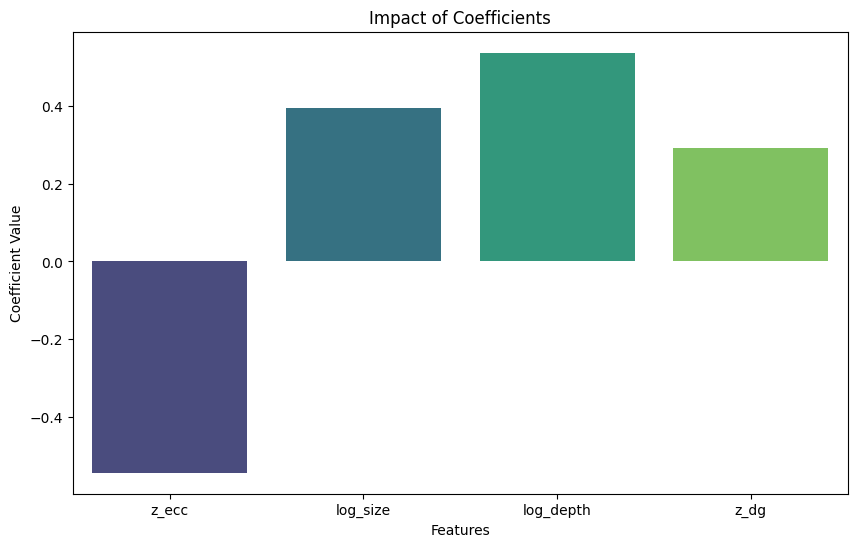

<ipython-input-6-c2604e8d439f>:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mae_per_scene_sorted.index, y=mae_per_scene_sorted.values, palette="Blues")


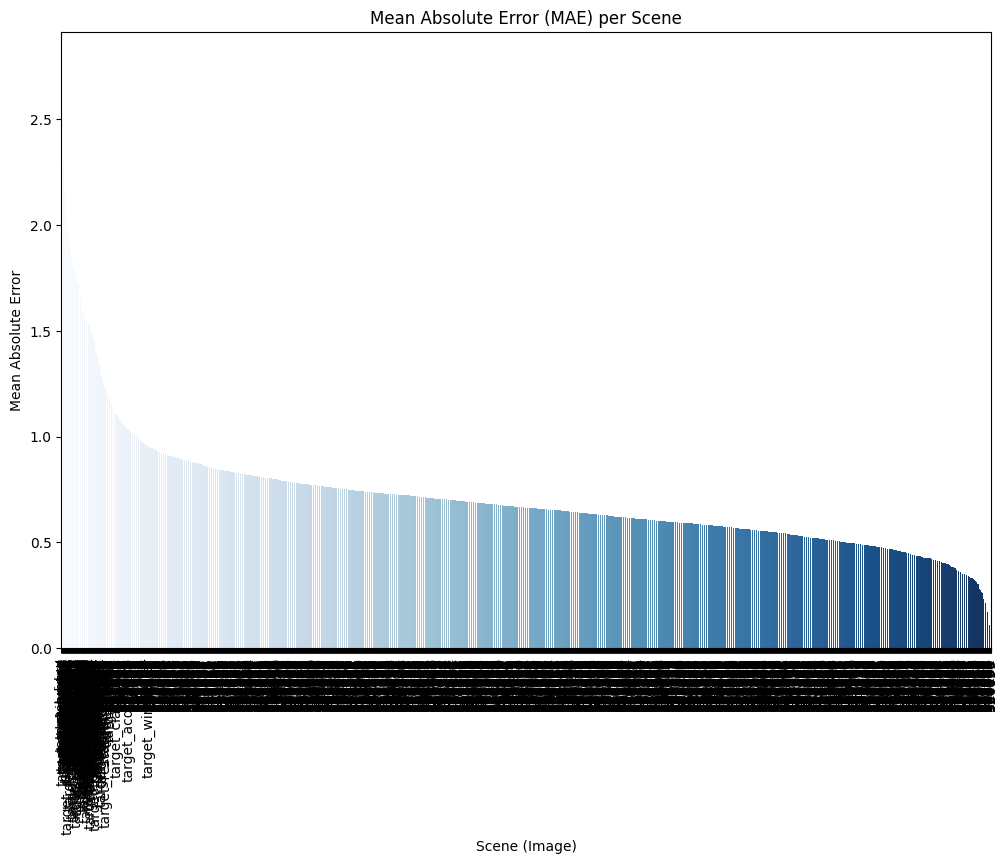

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import statsmodels.formula.api as smf
from scipy.stats import zscore

def plot_model_breakdown(values, model, y_true, y_pred):
    """
    Plot a breakdown of the model: impact of the coefficients and MAE for each scene.

    Args:
    values: DataFrame containing the features and target variables.
    model: Fitted LinearRegression model.
    y_true: Actual target values.
    y_pred: Predicted target values.
    """
    # Plot the impact of the coefficients
    coef = model.coef_
    feature_names = values[['z_ecc', 'log_size', 'log_depth', 'z_dg']].columns
    coef_df = pd.DataFrame(coef, index=feature_names, columns=["Coefficient"])

    plt.figure(figsize=(10, 6))
    sns.barplot(x=coef_df.index, y=coef_df["Coefficient"], palette="viridis")
    plt.title("Impact of Coefficients")
    plt.xlabel("Features")
    plt.ylabel("Coefficient Value")
    plt.show()

    # Calculate the mean absolute error (MAE) per scene
    values['mae'] = np.abs(y_true - y_pred)
    mae_per_scene = values.groupby('image')['mae'].mean()

    # Plot MAE per scene
    plt.figure(figsize=(12, 8))
    mae_per_scene_sorted = mae_per_scene.sort_values(ascending=False)
    sns.barplot(x=mae_per_scene_sorted.index, y=mae_per_scene_sorted.values, palette="Blues")
    plt.title("Mean Absolute Error (MAE) per Scene")
    plt.xlabel("Scene (Image)")
    plt.ylabel("Mean Absolute Error")
    plt.xticks(rotation=90)
    plt.show()

# Example of how to use this function:
# Assuming `values`, `model`, and `y_pred` are already defined
plot_model_breakdown(values, model, y, y_pred)


In [ ]:
coco['log_size'] = np.log1p(coco['size'])
coco['log_sum'] = np.log1p(coco['sum'])
coco['log_depth'] = np.log1p(coco['depth_center'])
coco['z_ecc'] = zscore(coco['ecc'])
coco['z_dg'] = zscore(coco['dg_center'])


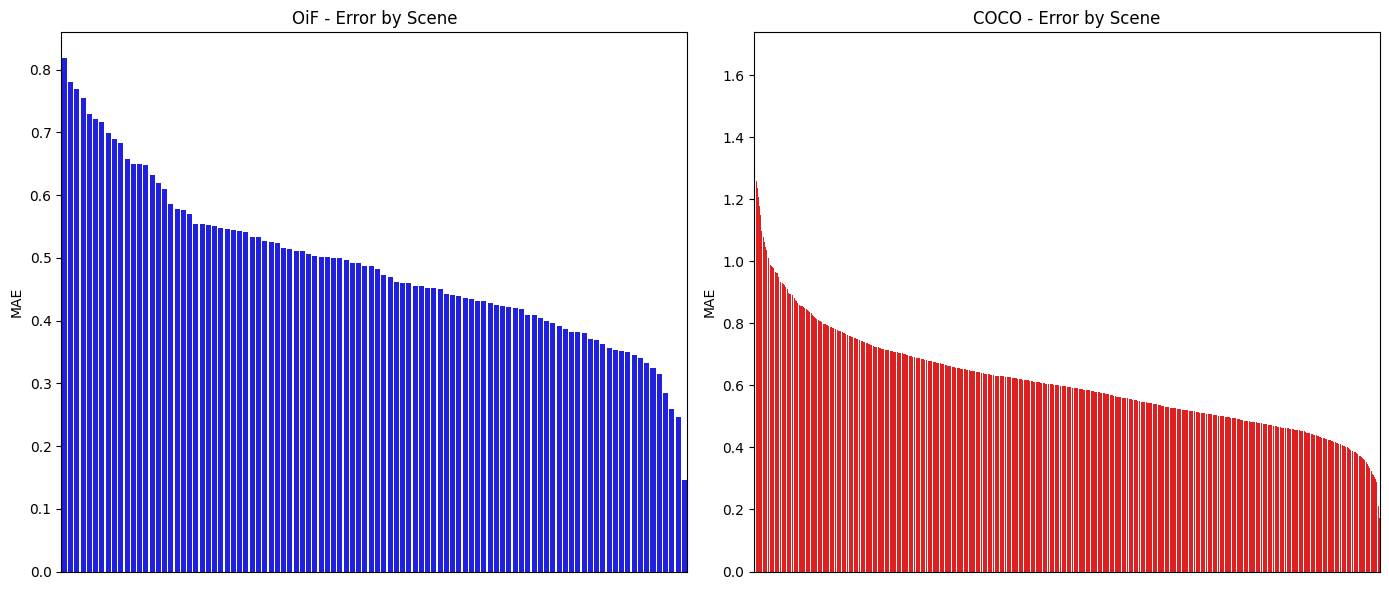

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_two_models_sorted_by_error(model1, values1, model2, values2):
    """
    Generate a figure with two plots for the different models and dataset values,
    sorted by average error (MAE) on the x-axis.

    Args:
    model1, model2: Fitted model objects for each dataset.
    values1, values2: DataFrame containing the features and target variables for each model.
    """
    # Create a figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Model 1 and Values 1: "OiF" in blue
    y_pred1 = model1.predict(values1[['z_ecc', 'log_size', 'log_depth', 'z_dg']])
    mae1 = np.abs(values1['log_sum'] - y_pred1)  # Using 'log_sum' as target

    # Calculate average MAE per image and sort
    mae1_per_image = mae1.groupby(values1['image']).mean().sort_values(ascending=False)

    sns.barplot(x=mae1_per_image.index, y=mae1_per_image.values, ax=axes[0], color="blue")
    axes[0].set_title("OiF - Error by Scene")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("MAE")
    axes[0].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    # Model 2 and Values 2: "COCO" in red
    y_pred2 = model2.predict(values2[['z_ecc', 'log_size', 'log_depth', 'z_dg']])
    mae2 = np.abs(values2['log_sum'] - y_pred2)  # Using 'log_sum' as target

    # Calculate average MAE per image and sort
    mae2_per_image = mae2.groupby(values2['image']).mean().sort_values(ascending=False)

    sns.barplot(x=mae2_per_image.index, y=mae2_per_image.values, ax=axes[1], color="red")
    axes[1].set_title("COCO - Error by Scene")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("MAE")
    axes[1].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()
    plt.savefig('MAE.png', dpi=500)
    files.download('MAE.png')

# Example of how to use this function:
# Assuming model_oif, oif, model_coco, coco are defined
plot_two_models_sorted_by_error(model_oif, oif, model_coco, coco)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

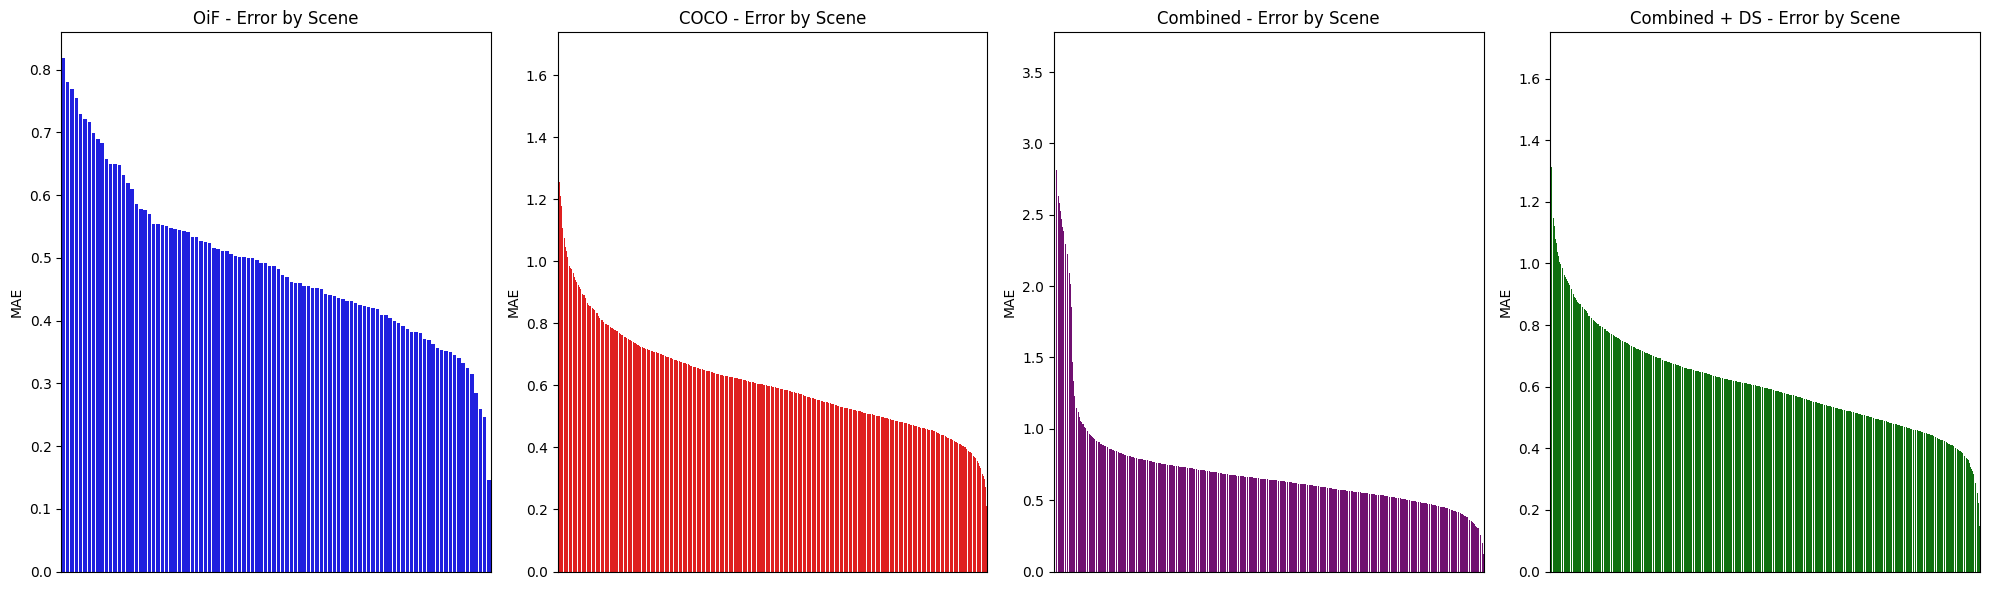

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_four_models_sorted_by_error(model1, values1, model2, values2, model3, values3, model4, values4):
    """
    Generate a figure with four plots for the different models and dataset values,
    sorted by average error (MAE) on the x-axis.

    Args:
    model1, model2, model3, model4: Fitted model objects for each dataset.
    values1, values2, values3, values4: DataFrame containing the features and target variables for each model.
    """
    # Create a figure with subplots
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))

    # Model 1 and Values 1: "OiF" in blue
    y_pred1 = model1.predict(values1[['z_ecc', 'log_size', 'log_depth', 'z_dg']])
    mae1 = np.abs(values1['log_sum'] - y_pred1)  # Using 'log_sum' as target

    # Calculate average MAE per image and sort
    mae1_per_image = mae1.groupby(values1['image']).mean().sort_values(ascending=False)

    sns.barplot(x=mae1_per_image.index, y=mae1_per_image.values, ax=axes[0], color="blue")
    axes[0].set_title("OiF - Error by Scene")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("MAE")
    axes[0].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    # Model 2 and Values 2: "COCO" in red
    y_pred2 = model2.predict(values2[['z_ecc', 'log_size', 'log_depth', 'z_dg']])
    mae2 = np.abs(values2['log_sum'] - y_pred2)  # Using 'log_sum' as target

    # Calculate average MAE per image and sort
    mae2_per_image = mae2.groupby(values2['image']).mean().sort_values(ascending=False)

    sns.barplot(x=mae2_per_image.index, y=mae2_per_image.values, ax=axes[1], color="red")
    axes[1].set_title("COCO - Error by Scene")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("MAE")
    axes[1].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    # Model 3 and Values 3: "Combined" in purple
    y_pred3 = model3.predict(values3[['z_ecc', 'log_size', 'log_depth', 'z_dg']])
    mae3 = np.abs(values3['log_sum'] - y_pred3)  # Using 'log_sum' as target

    # Calculate average MAE per image and sort
    mae3_per_image = mae3.groupby(values3['image']).mean().sort_values(ascending=False)

    sns.barplot(x=mae3_per_image.index, y=mae3_per_image.values, ax=axes[2], color="purple")
    axes[2].set_title("Combined - Error by Scene")
    axes[2].set_xlabel("")
    axes[2].set_ylabel("MAE")
    axes[2].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    # Model 4 and Values 4: "Combined + DS" in green
    values4 = pd.get_dummies(values4, columns=['ds'], drop_first=True)
    y_pred4 = model4.predict(values4[['z_ecc', 'log_size', 'log_depth', 'z_dg', 'ds_oif']])
    mae4 = np.abs(values4['log_sum'] - y_pred4)  # Using 'log_sum' as target

    # Calculate average MAE per image and sort
    mae4_per_image = mae4.groupby(values4['image']).mean().sort_values(ascending=False)

    sns.barplot(x=mae4_per_image.index, y=mae4_per_image.values, ax=axes[3], color="green")
    axes[3].set_title("Combined + DS - Error by Scene")
    axes[3].set_xlabel("")
    axes[3].set_ylabel("MAE")
    axes[3].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)

    # Adjust layout and show the plot
    plt.tight_layout()
    #plt.show()

    # Save the figure as 'MAE.png' with dpi 500
    plt.savefig('MAE.png', dpi=300, bbox_inches='tight')


    # Download the figure (only for Google Colab environment)
    try:
        from google.colab import files
        files.download('MAE.png')
    except ImportError:
        print("Download functionality not available outside of Google Colab.")

# Example of how to use this functio
plot_four_models_sorted_by_error(model_oif, oif, model_coco, coco, model_combo, combo, model_cds, combo)


In [ ]:
coco['image'] = coco['image'].astype(str)

In [ ]:
combo = pd.concat([oif, coco])
oif['log_size'] = np.log1p(oif['size'])
oif['log_sum'] = np.log1p(oif['sum'])
oif['log_depth'] = np.log1p(oif['depth_center'])
oif['z_ecc'] = zscore(oif['ecc'])
oif['z_dg'] = zscore(oif['dg_center'])

In [ ]:
combo = pd.concat([oif, coco])
combo['log_size'] = np.log1p(combo['size'])
combo['log_sum'] = np.log1p(combo['sum'])
combo['log_depth'] = np.log1p(combo['depth_center'])
combo['z_ecc'] = zscore(combo['ecc'])
combo['z_dg'] = zscore(combo['dg_center'])


In [ ]:
coco['log_size'] = np.log1p(coco['size'])
coco['log_sum'] = np.log1p(coco['sum'])
coco['log_depth'] = np.log1p(coco['depth_center'])
coco['z_ecc'] = zscore(coco['ecc'])
coco['z_dg'] = zscore(coco['dg_center'])
oif['log_size'] = np.log1p(oif['size'])
oif['log_sum'] = np.log1p(oif['sum'])
oif['log_depth'] = np.log1p(oif['depth_center'])
oif['z_ecc'] = zscore(oif['ecc'])
oif['z_dg'] = zscore(oif['dg_center'])

In [ ]:
# Assuming 'values' is your DataFrame
# One-hot encode the 'ds' variable
values_encoded = pd.get_dummies(values, columns=['ds'], drop_first=True)  # drop_first to avoid multicollinearity

# Define X and y for model fitting
X_cds = values_encoded[['z_ecc', 'log_size', 'log_depth', 'z_dg', 'ds_oif']]  # Assuming 'ds_oif' is the encoded column
y_cds = values['log_sum']

model_cds = LinearRegression()
model_cds.fit(X_cds, y_cds)
y_pred_cds = model_cds.predict(X_cds)

In [ ]:
coco = coco[['image', 'label', 'sum', 'size', 'ecc', 'dg_center', 'depth_center']].copy()
coco['ds'] = 'coco'
oif = oif[['image', 'label', 'sum', 'size', 'ecc', 'dg_center', 'depth_center']].copy()
oif['ds'] = 'oif'
values = pd.concat([coco, oif])

values['log_size'] = np.log1p(values['size'])
values['log_sum'] = np.log1p(values['sum'])
values['log_depth'] = np.log1p(values['depth_center'])
values['z_ecc'] = zscore(values['ecc'])
values['z_dg'] = zscore(values['dg_center'])

# Fit the model and get predictions
X_combo = values[['z_ecc', 'log_size', 'log_depth', 'z_dg']]
y_combo = values['log_sum']
model_combo = LinearRegression()
model_combo.fit(X_combo, y_combo)
y_pred_combo = model_combo.predict(X_combo)

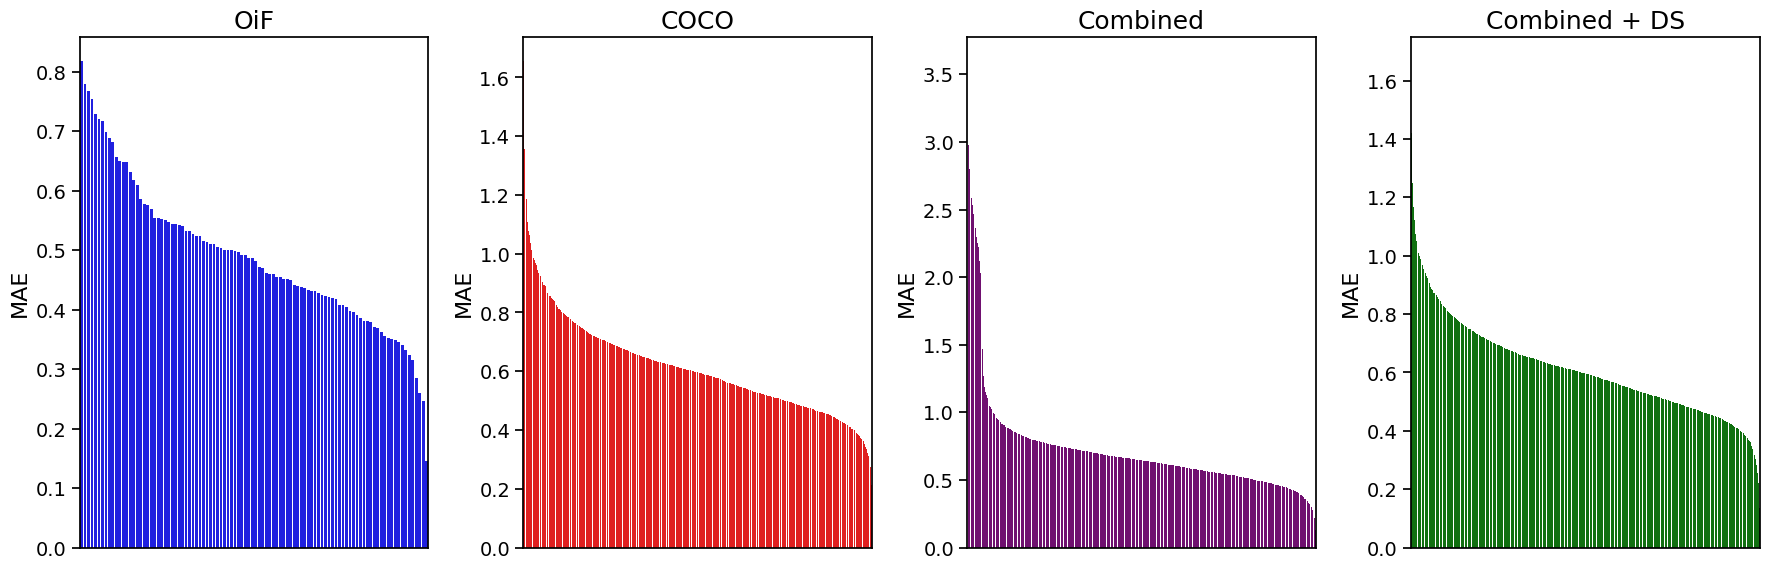

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_four_models_sorted_by_error(model1, values1, model2, values2, model3, values3, model4, values4):
    """
    Generate a figure with four plots for the different models and dataset values,
    sorted by average error (MAE) on the x-axis, with further increased font size.

    Args:
    model1, model2, model3, model4: Fitted model objects for each dataset.
    values1, values2, values3, values4: DataFrame containing the features and target variables for each model.
    """
    # Set font size for seaborn (increased)
    sns.set_context("notebook", font_scale=1.4)  # Further increase font size

    # Create a figure with subplots
    fig, axes = plt.subplots(1, 4, figsize=(18, 6))  # Slightly larger figure

    models = [model1, model2, model3, model4]
    values = [values1, values2, values3, values4]
    colors = ["blue", "red", "purple", "green"]
    titles = ["OiF", "COCO", "Combined", "Combined + DS"]

    for i, (model, val, color, title) in enumerate(zip(models, values, colors, titles)):
        if i == 3:  # One-hot encoding only for 4th model
            val = pd.get_dummies(val, columns=['ds'], drop_first=True)

        features = ['z_ecc', 'log_size', 'log_depth', 'z_dg']
        if i == 3:  # Include one-hot encoded column for model 4
            features.append('ds_oif')

        y_pred = model.predict(val[features])
        mae = np.abs(val['log_sum'] - y_pred)

        # Check if 'image' column exists and is properly formatted
        if 'image' not in val.columns:
            print(f"Warning: 'image' column missing in dataset {i+1}")
            continue

        mae_per_image = mae.groupby(val['image']).mean().sort_values(ascending=False)

        sns.barplot(x=mae_per_image.index, y=mae_per_image.values, ax=axes[i], color=color)
        axes[i].set_title(title, fontsize=18)  # Increase title font size
        axes[i].set_xlabel("", fontsize=16)
        axes[i].set_ylabel("MAE", fontsize=16)
        axes[i].tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
        axes[i].tick_params(axis="y", labelsize=14)  # Increase tick label font size

    # Adjust layout and save the figure
    plt.tight_layout()
    plt.savefig('MAE.png', dpi=800, bbox_inches='tight')
    plt.show()  # Ensure plot renders before saving
    plt.close(fig)  # Close the figure to avoid blank downloads

    # Download the figure (only for Google Colab environment)
    try:
        from google.colab import files
        files.download('MAE.png')
    except ImportError:
        print("Download functionality not available outside of Google Colab.")

# Example usage:
plot_four_models_sorted_by_error(model_oif, oif, model_coco, coco, model_combo, combo, model_cds, combo)


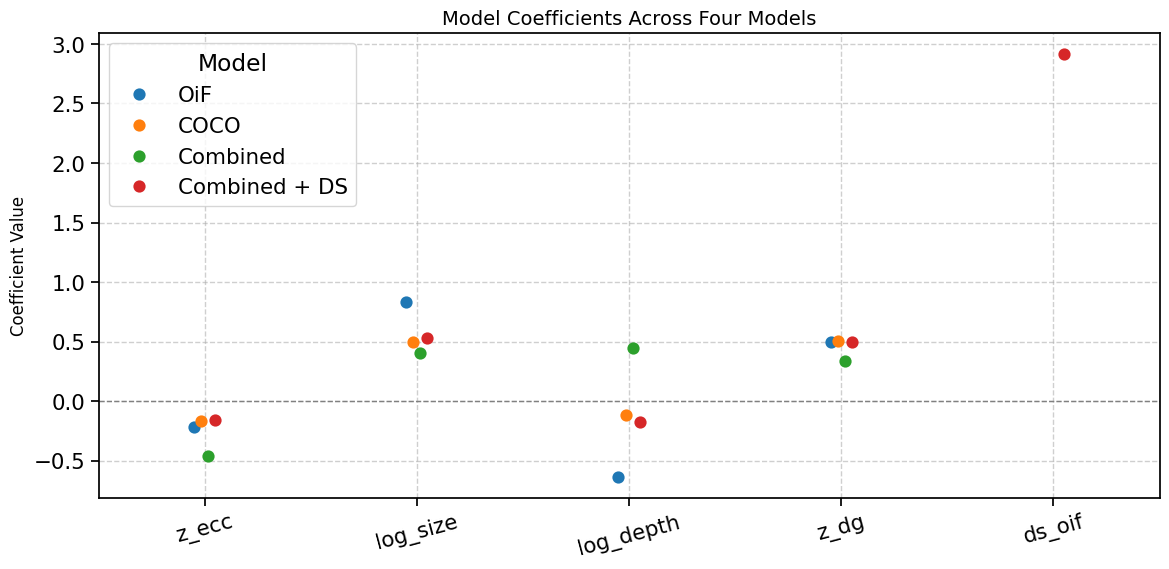

NameError: name 'fig' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_model_coefficients(models, model_names, feature_lists):
    """
    Plot the coefficients of different models using a point plot.

    Args:
    models: List of fitted models.
    model_names: List of model names (strings).
    feature_lists: List of feature names used for training each model.
    """
    # Collect coefficients from all models
    coef_data = []

    for model, name, features in zip(models, model_names, feature_lists):
        coef = model.coef_

        # Ensure the length of coefficients matches the number of features used in training
        if len(coef) != len(features):
            print(f"Warning: Model {name} has {len(coef)} coefficients but was trained with {len(features)} features. Skipping.")
            continue  # Skip models with mismatched coefficients

        coef_df = pd.DataFrame({"Feature": features, "Coefficient": coef, "Model": name})
        coef_data.append(coef_df)

    # Concatenate all coefficient data
    if not coef_data:
        print("No valid model coefficient data to plot.")
        return

    coef_data = pd.concat(coef_data)

    # Plot the coefficients using a point plot
    plt.figure(figsize=(12, 6))
    sns.pointplot(data=coef_data, x="Feature", y="Coefficient", hue="Model", dodge=True, markers="o", linestyles="")
    plt.axhline(0, color="gray", linestyle="--", linewidth=1)  # Add reference line at 0
    plt.title("Model Coefficients Across Four Models", fontsize=14)
    plt.xlabel("")
    plt.ylabel("Coefficient Value", fontsize=12)
    plt.xticks(rotation=15)
    plt.legend(title="Model")
    plt.grid(True, linestyle="--", alpha=0.6)

        # Adjust layout and save the figure
    plt.tight_layout()
    plt.savefig('coeff.png', dpi=600, bbox_inches='tight')
    plt.show()  # Ensure plot renders before saving
    plt.close(fig)  # Close the figure to avoid blank downloads

    # Download the figure (only for Google Colab environment)
    try:
        from google.colab import files
        files.download('coeff.png')
    except ImportError:
        print("Download functionality not available outside of Google Colab.")

# Define the exact features used in training for each model
features_oif = ['z_ecc', 'log_size', 'log_depth', 'z_dg']
features_coco = ['z_ecc', 'log_size', 'log_depth', 'z_dg']
features_combo = ['z_ecc', 'log_size', 'log_depth', 'z_dg']
features_cds = ['z_ecc', 'log_size', 'log_depth', 'z_dg', 'ds_oif']  # Model 4 includes one-hot encoding

# Example usage:
plot_model_coefficients(
    models=[model_oif, model_coco, model_combo, model_cds],
    model_names=["OiF", "COCO", "Combined", "Combined + DS"],
    feature_lists=[features_oif, features_coco, features_combo, features_cds]
)



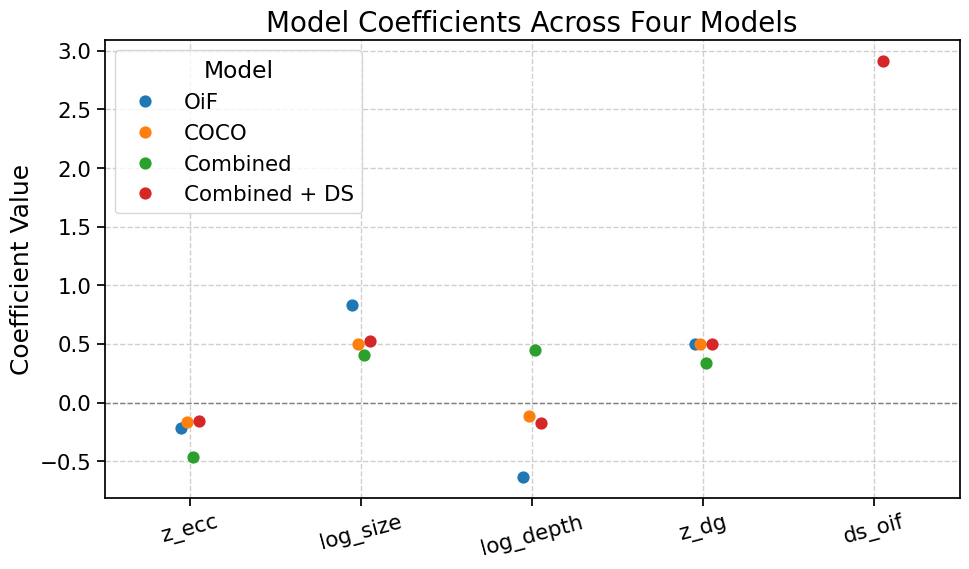

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_model_coefficients(models, model_names, feature_lists):
    """
    Plot the coefficients of different models using a point plot and save the figure.

    Args:
    models: List of fitted models.
    model_names: List of model names (strings).
    feature_lists: List of feature names used for training each model.
    """
    # Collect coefficients from all models
    coef_data = []

    for model, name, features in zip(models, model_names, feature_lists):
        coef = model.coef_

        # Ensure the length of coefficients matches the number of features used in training
        if len(coef) != len(features):
            print(f"Warning: Model {name} has {len(coef)} coefficients but was trained with {len(features)} features. Skipping.")
            continue  # Skip models with mismatched coefficients

        coef_df = pd.DataFrame({"Feature": features, "Coefficient": coef, "Model": name})
        coef_data.append(coef_df)

    # Concatenate all coefficient data
    if not coef_data:
        print("No valid model coefficient data to plot.")
        return

    coef_data = pd.concat(coef_data)

    # Plot the coefficients using a point plot
    fig, ax = plt.subplots(figsize=(10, 6))  # Define figure instance

    sns.pointplot(data=coef_data, x="Feature", y="Coefficient", hue="Model", dodge=True, markers="o", linestyles="", ax=ax)
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)  # Add reference line at 0
    ax.set_title("Model Coefficients Across Four Models", fontsize=20)
    ax.set_xlabel("")
    ax.set_ylabel("Coefficient Value", fontsize=18)
    ax.tick_params(axis="x", rotation=15)
    ax.legend(title="Model")
    ax.grid(True, linestyle="--", alpha=0.6)

    # Adjust layout and save the figure
    plt.tight_layout()
    save_path = "coeff.png"
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()  # Ensure plot renders before saving
    plt.close(fig)  # Close the figure to free memory

    # Download the figure (only for Google Colab environment)
    try:
        from google.colab import files
        files.download(save_path)
    except ImportError:
        print("Download functionality not available outside of Google Colab.")

# Define the exact features used in training for each model
features_oif = ['z_ecc', 'log_size', 'log_depth', 'z_dg']
features_coco = ['z_ecc', 'log_size', 'log_depth', 'z_dg']
features_combo = ['z_ecc', 'log_size', 'log_depth', 'z_dg']
features_cds = ['z_ecc', 'log_size', 'log_depth', 'z_dg', 'ds_oif']  # Model 4 includes one-hot encoding

# Example usage:
plot_model_coefficients(
    models=[model_oif, model_coco, model_combo, model_cds],
    model_names=["OiF", "COCO", "Combined", "Combined + DS"],
    feature_lists=[features_oif, features_coco, features_combo, features_cds]
)


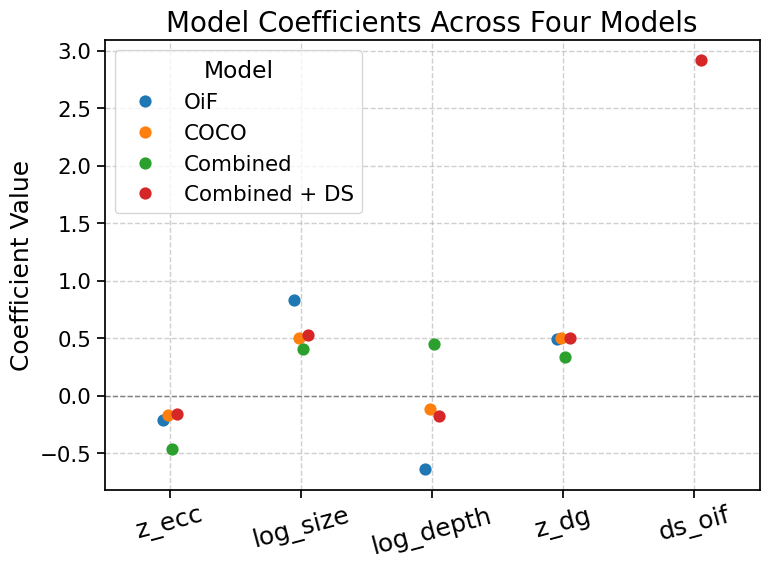

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_model_coefficients(models, model_names, feature_lists):
    """
    Plot the coefficients of different models using a point plot and save the figure.

    Args:
    models: List of fitted models.
    model_names: List of model names (strings).
    feature_lists: List of feature names used for training each model.
    """
    # Collect coefficients from all models
    coef_data = []

    for model, name, features in zip(models, model_names, feature_lists):
        coef = model.coef_

        # Ensure the length of coefficients matches the number of features used in training
        if len(coef) != len(features):
            print(f"Warning: Model {name} has {len(coef)} coefficients but was trained with {len(features)} features. Skipping.")
            continue  # Skip models with mismatched coefficients

        coef_df = pd.DataFrame({"Feature": features, "Coefficient": coef, "Model": name})
        coef_data.append(coef_df)

    # Concatenate all coefficient data
    if not coef_data:
        print("No valid model coefficient data to plot.")
        return

    coef_data = pd.concat(coef_data)

    # Plot the coefficients using a point plot
    fig, ax = plt.subplots(figsize=(8, 6))  # Define figure instance

    sns.pointplot(data=coef_data, x="Feature", y="Coefficient", hue="Model", dodge=True, markers="o", linestyles="", ax=ax)
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)  # Add reference line at 0
    ax.set_title("Model Coefficients Across Four Models", fontsize=20)
    ax.set_xlabel("")
    ax.set_ylabel("Coefficient Value", fontsize=18)
    ax.tick_params(axis="x", rotation=15, labelsize=18)  # Increased font size for x-ticks
    ax.legend(title="Model")
    ax.grid(True, linestyle="--", alpha=0.6)

    # Adjust layout and save the figure
    plt.tight_layout()
    save_path = "coeff.png"
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()  # Ensure plot renders before saving
    plt.close(fig)  # Close the figure to free memory

    # Download the figure (only for Google Colab environment)
    try:
        from google.colab import files
        files.download(save_path)
    except ImportError:
        print("Download functionality not available outside of Google Colab.")

# Define the exact features used in training for each model
features_oif = ['z_ecc', 'log_size', 'log_depth', 'z_dg']
features_coco = ['z_ecc', 'log_size', 'log_depth', 'z_dg']
features_combo = ['z_ecc', 'log_size', 'log_depth', 'z_dg']
features_cds = ['z_ecc', 'log_size', 'log_depth', 'z_dg', 'ds_oif']  # Model 4 includes one-hot encoding

# Example usage:
plot_model_coefficients(
    models=[model_oif, model_coco, model_combo, model_cds],
    model_names=["OiF", "COCO", "Combined", "Combined + DS"],
    feature_lists=[features_oif, features_coco, features_combo, features_cds]
)


In [ ]:
values = oif

values['log_size'] = np.log1p(values['size'])
values['log_sum'] = np.log1p(values['sum'])
values['log_depth'] = np.log1p(values['depth_center'])
values['z_ecc'] = zscore(values['ecc'])
values['z_dg'] = zscore(values['dg_center'])
mod = smf.ols(formula='log_sum ~ log_depth + z_ecc + log_size + z_dg', data=values)
res = mod.fit()
print(res.summary())

# Fit the model and get predictions
X_oif = values[['z_ecc', 'log_size', 'log_depth', 'z_dg']]
y_oif = values['log_sum']
model_oif = LinearRegression()
model_oif.fit(X_oif, y_oif)
y_pred_oif = model_oif.predict(X_oif)

                            OLS Regression Results                            
Dep. Variable:                log_sum   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     2920.
Date:                Sat, 08 Mar 2025   Prob (F-statistic):               0.00
Time:                        05:48:20   Log-Likelihood:                -2483.3
No. Observations:                2493   AIC:                             4977.
Df Residuals:                    2488   BIC:                             5006.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.3704      0.073    -45.969      0.0

In [ ]:


values['log_size'] = np.log1p(values['size'])
values['log_sum'] = np.log1p(values['sum'])
values['log_depth'] = np.log1p(values['depth_center'])
values['z_ecc'] = zscore(values['ecc'])
values['z_dg'] = zscore(values['dg_center'])
mod = smf.ols(formula='log_sum ~ log_depth + z_ecc + log_size + z_dg', data=values)
res = mod.fit()
print(res.summary())

# Fit the model and get predictions
X_oif = values[['z_ecc', 'log_size', 'log_depth', 'z_dg']]
y_oif = values['log_sum']
model_oif = LinearRegression()
model_oif.fit(X_oif, y_oif)
y_pred_oif = model_oif.predict(X_oif)

In [ ]:
values = coco

values['log_size'] = np.log1p(values['size'])
values['log_sum'] = np.log1p(values['sum'])
values['log_depth'] = np.log1p(values['depth_center'])
values['z_ecc'] = zscore(values['ecc'])
values['z_dg'] = zscore(values['dg_center'])
mod = smf.ols(formula='log_sum ~ log_depth + z_ecc + log_size + z_dg', data=values)
res = mod.fit()
print(res.summary())

# Fit the model and get predictions
X_coco = values[['z_ecc', 'log_size', 'log_depth', 'z_dg']]
y_coco = values['log_sum']
model_coco = LinearRegression()
model_coco.fit(X_coco, y_coco)
y_pred_coco = model_coco.predict(X_coco)

                            OLS Regression Results                            
Dep. Variable:                log_sum   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.665
Method:                 Least Squares   F-statistic:                 1.543e+04
Date:                Sat, 08 Mar 2025   Prob (F-statistic):               0.00
Time:                        05:45:10   Log-Likelihood:                -34331.
No. Observations:               31138   AIC:                         6.867e+04
Df Residuals:                   31133   BIC:                         6.871e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.7519      0.029   -128.620      0.0

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

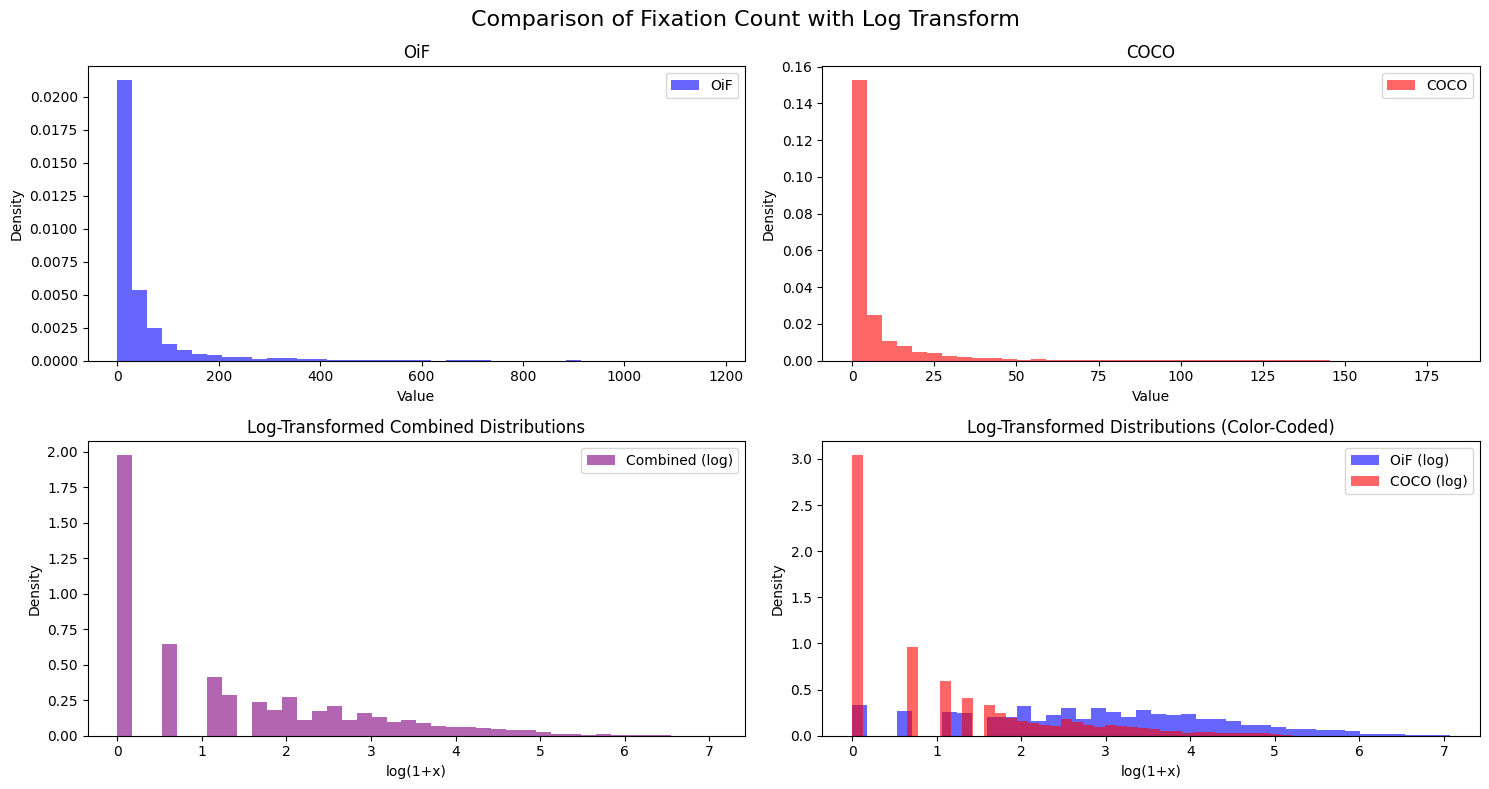

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from typing import Tuple, List, Union, Optional, Dict, Any

def plot_distributions_log(
    dist1: np.ndarray,
    dist2: np.ndarray,
    bins: int = 30,
    labels: Tuple[str, str] = ("Distribution 1", "Distribution 2"),
    colors: Tuple[str, str] = ("blue", "red"),
    alpha: float = 0.6,
    title: str = "Distribution Comparison",
    figsize: Tuple[int, int] = (15, 8),
    density: bool = True,
    show_combined: bool = True,
    show_log_combined: bool = True,
    combined_color: str = "purple",
    x_label: Optional[str] = None,
    y_label: Optional[str] = None,
    save_path: Optional[str] = None
) -> Tuple[Figure, List, Dict[str, Any]]:
    """
    Plot two distributions separately and combined, with optional log transformation of combined data.
    The log-transformed plot is color-coded based on source distribution.

    Parameters:
    -----------
    dist1, dist2 : np.ndarray
        Arrays containing the data for each distribution
    bins : int
        Number of histogram bins
    labels : Tuple[str, str]
        Labels for the two distributions
    colors : Tuple[str, str]
        Colors for the two distributions
    alpha : float
        Transparency level for histograms (0 to 1)
    title : str
        Main title for the figure
    figsize : Tuple[int, int]
        Size of the figure (width, height)
    density : bool
        Whether to normalize the histograms to form a density
    show_combined : bool
        Whether to show the combined distribution
    show_log_combined : bool
        Whether to show the log1p transform of the combined distribution
    combined_color : str
        Color for the combined distribution (non-color-coded version)
    x_label : Optional[str]
        Label for x-axis (if None, no label is shown)
    y_label : Optional[str]
        Label for y-axis (defaults to "Density" or "Count" based on density parameter)
    save_path : Optional[str]
        If provided, save the figure to this path

    Returns:
    --------
    Tuple[Figure, List, Dict]
        The Figure object, list of Axes objects, and a dictionary of the data
    """
    # Set the y_label based on density parameter if not provided
    if y_label is None:
        y_label = "Density" if density else "Count"

    # Define the original distributions for plotting
    # Remove NaNs and infinite values
    dist1 = dist1[np.isfinite(dist1)]
    dist2 = dist2[np.isfinite(dist2)]

    dist1_plot = dist1.copy()
    dist2_plot = dist2.copy()

    dist1_df = pd.DataFrame()
    dist1_df['value'] = dist1
    dist1_df['dist'] = '1'

    dist2_df = pd.DataFrame()
    dist2_df['value'] = dist2
    dist2_df['dist'] = '2'

    # Create the combined distribution
    #combined_data = np.concatenate([dist1, dist2])

    combined_data = pd.concat([dist1_df, dist2_df])

    combined_data['log'] = np.log1p(combined_data['value'])
    combined_data = combined_data.replace([np.inf, -np.inf], np.nan).dropna()
    log_data_1 = list(combined_data[combined_data['dist']=='1']['log'])
    log_data_2 = list(combined_data[combined_data['dist']=='2']['log'])
    # Create the log-transformed versions of each distribution
    #log_dist1 = np.log1p(dist1)
    #log_dist2 = np.log1p(dist2)

    # Log-transform the combined data
    #log_combined_data = np.log1p(combined_data)

    # Determine number of subplots needed (we want all 4 plots)
    n_plots = 4

    # Create 2x2 grid for the subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()

    # Plot first distribution
    axes[0].hist(dist1_plot, bins=bins, color=colors[0], alpha=alpha, density=density, label=labels[0])
    axes[0].set_title(f"{labels[0]}")
    if x_label:
        axes[0].set_xlabel(x_label)
    else:
        axes[0].set_xlabel("Value")
    axes[0].set_ylabel(y_label)
    axes[0].legend()

    # Plot second distribution
    axes[1].hist(dist2_plot, bins=bins, color=colors[1], alpha=alpha, density=density, label=labels[1])
    axes[1].set_title(f"{labels[1]}")
    if x_label:
        axes[1].set_xlabel(x_label)
    else:
        axes[1].set_xlabel("Value")
    axes[1].set_ylabel(y_label)
    axes[1].legend()

    # Plot log-transformed combined distribution with a single color
    if show_combined:
        axes[2].hist(combined_data['log'], bins=bins, color=combined_color, alpha=alpha,
                   density=density, label="Combined (log)")
        axes[2].set_title("Log-Transformed Combined Distributions")
        axes[2].set_xlabel("log(1+x)")
        axes[2].set_ylabel(y_label)
        axes[2].legend()

    # Plot log-transformed combined distribution with color coding
    if show_log_combined:
      # Separate data by source

      # Remove NaN or infinite values
      #log_data_1 = log_data_1[np.isfinite(log_data_1)]
      #log_data_2 = log_data_2[np.isfinite(log_data_2)]
      # Plot the log-transformed histograms with separate colors
      axes[3].hist(log_data_1, bins=bins, color=colors[0], alpha=alpha,
                  density=density, label=f"{labels[0]} (log)")
      axes[3].hist(log_data_2, bins=bins, color=colors[1], alpha=alpha,
                  density=density, label=f"{labels[1]} (log)")

      axes[3].set_title("Log-Transformed Distributions (Color-Coded)")
      axes[3].set_xlabel("log(1+x)")
      axes[3].set_ylabel(y_label)
      axes[3].legend()

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        files.download(save_path)

    return fig, axes, {
        "original_distributions": (dist1_plot, dist2_plot),
        "log_combined": combined_data,
        "log_distributions": (log_data_1, log_data_2)
    }

# Example usage
if __name__ == "__main__":

    # Plot the distributions
    fig, axes, data = plot_distributions_log(
       oif['sum'],
       coco['sum'],
        bins=40,
        labels=("OiF", "COCO"),
        colors=("blue", "red"),
        combined_color="purple",
        title="Comparison of Fixation Count with Log Transform",
        save_path='fix_count.png',
         # Change to a path if you want to save the figure
    )

    plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

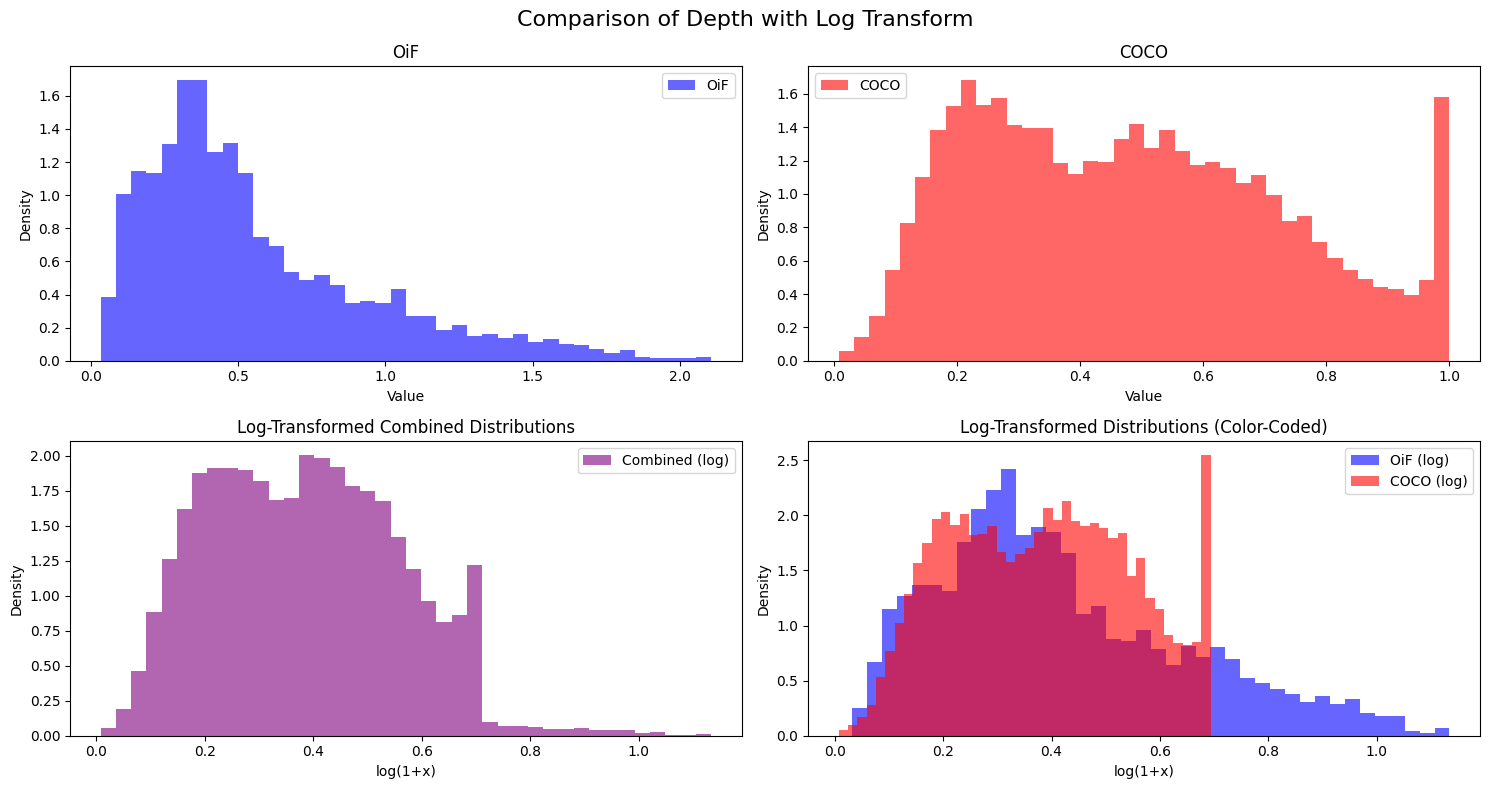

In [ ]:
# Example usage
if __name__ == "__main__":

    # Plot the distributions
    fig, axes, data = plot_distributions_log(
       oif['depth_center'],
       coco['depth_center'],
        bins=40,
        labels=("OiF", "COCO"),
        colors=("blue", "red"),
        combined_color="purple",
        title="Comparison of Depth with Log Transform",
        save_path='depth.png'  # Change to a path if you want to save the figure
    )

    plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

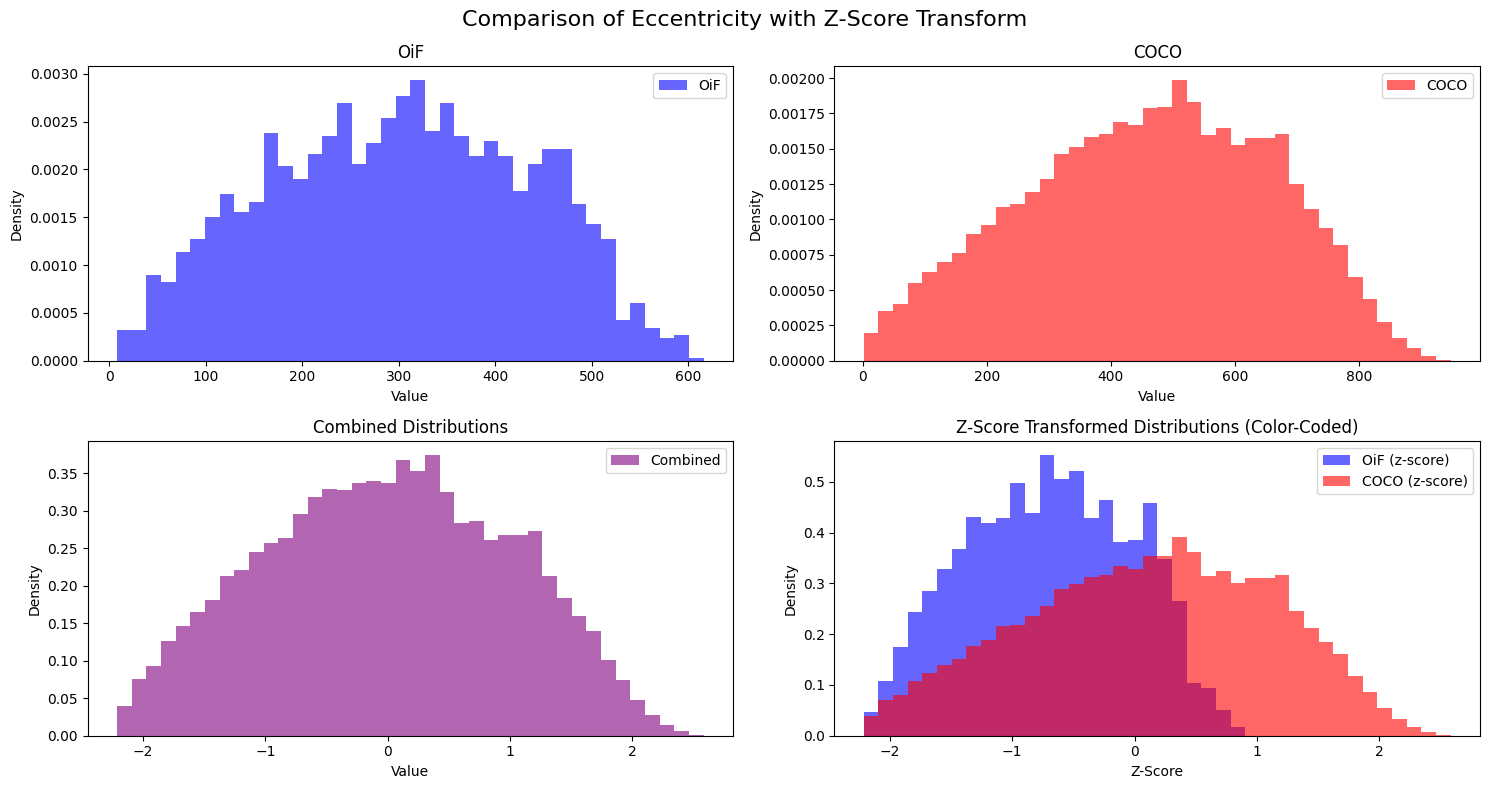

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.figure import Figure
from typing import Tuple, List, Union, Optional, Dict, Any

def plot_distributions_z(
    dist1: np.ndarray,
    dist2: np.ndarray,
    bins: int = 30,
    labels: Tuple[str, str] = ("Distribution 1", "Distribution 2"),
    colors: Tuple[str, str] = ("blue", "red"),
    alpha: float = 0.6,
    title: str = "Distribution Comparison",
    figsize: Tuple[int, int] = (15, 8),
    density: bool = True,
    show_combined: bool = True,
    show_zscore_combined: bool = True,
    combined_color: str = "purple",
    x_label: Optional[str] = None,
    y_label: Optional[str] = None,
    save_path: Optional[str] = None
) -> Tuple[Figure, List, Dict[str, Any]]:
    """
    Plot two distributions separately and combined, with optional z-score transformation of combined data.
    The z-score transformed plot is color-coded based on source distribution.
    """
    if y_label is None:
        y_label = "Density" if density else "Count"

    # Create DataFrames for distributions
    # Remove NaNs and infinite values
    dist1 = dist1[np.isfinite(dist1)]
    dist2 = dist2[np.isfinite(dist2)]

    dist1_df = pd.DataFrame({"value": dist1, "dist": "1"})
    dist2_df = pd.DataFrame({"value": dist2, "dist": "2"})

    # Combine data
    combined_data = pd.concat([dist1_df, dist2_df])

    # Z-score transformation
    combined_data["zscore"] = (combined_data["value"] - combined_data["value"].mean()) / combined_data["value"].std()

    zscore_dist1 = list(combined_data[combined_data["dist"] == "1"]["zscore"])
    zscore_dist2 = list(combined_data[combined_data["dist"] == "2"]["zscore"])

    # Create 2x2 grid for the subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()

    # Plot first distribution
    axes[0].hist(dist1, bins=bins, color=colors[0], alpha=alpha, density=density, label=labels[0])
    axes[0].set_title(f"{labels[0]}")
    axes[0].set_xlabel(x_label if x_label else "Value")
    axes[0].set_ylabel(y_label)
    axes[0].legend()

    # Plot second distribution
    axes[1].hist(dist2, bins=bins, color=colors[1], alpha=alpha, density=density, label=labels[1])
    axes[1].set_title(f"{labels[1]}")
    axes[1].set_xlabel(x_label if x_label else "Value")
    axes[1].set_ylabel(y_label)
    axes[1].legend()

    # Plot combined distribution
    if show_combined:
        axes[2].hist((combined_data["value"] - combined_data["value"].mean()) / combined_data["value"].std(), bins=bins, color=combined_color, alpha=alpha, density=density, label="Combined")
        axes[2].set_title("Combined Distributions")
        axes[2].set_xlabel("Value")
        axes[2].set_ylabel(y_label)
        axes[2].legend()

    # Plot z-score transformed combined distribution with color coding
    if show_zscore_combined:
        min_z, max_z = min(zscore_dist1 + zscore_dist2), max(zscore_dist1 + zscore_dist2)
        zscore_bin_edges = np.linspace(min_z, max_z, bins + 1)

        axes[3].hist(zscore_dist1, bins=zscore_bin_edges, color=colors[0], alpha=alpha, density=density, label=f"{labels[0]} (z-score)")
        axes[3].hist(zscore_dist2, bins=zscore_bin_edges, color=colors[1], alpha=alpha, density=density, label=f"{labels[1]} (z-score)")

        axes[3].set_title("Z-Score Transformed Distributions (Color-Coded)")
        axes[3].set_xlabel("Z-Score")
        axes[3].set_ylabel(y_label)
        axes[3].legend()

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        files.download(save_path)

    return fig, axes, {
        "original_distributions": (dist1, dist2),
        "zscore_combined": combined_data,
        "zscore_distributions": (zscore_dist1, zscore_dist2)
    }

# Example usage
if __name__ == "__main__":

    # Plot the distributions
    fig, axes, data = plot_distributions_z(
       oif['ecc'],
       coco['ecc'],
        bins=40,
        labels=("OiF", "COCO"),
        colors=("blue", "red"),
        combined_color="purple",
        title="Comparison of Eccentricity with Z-Score Transform",
        save_path='ecc.png',
    )

    plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

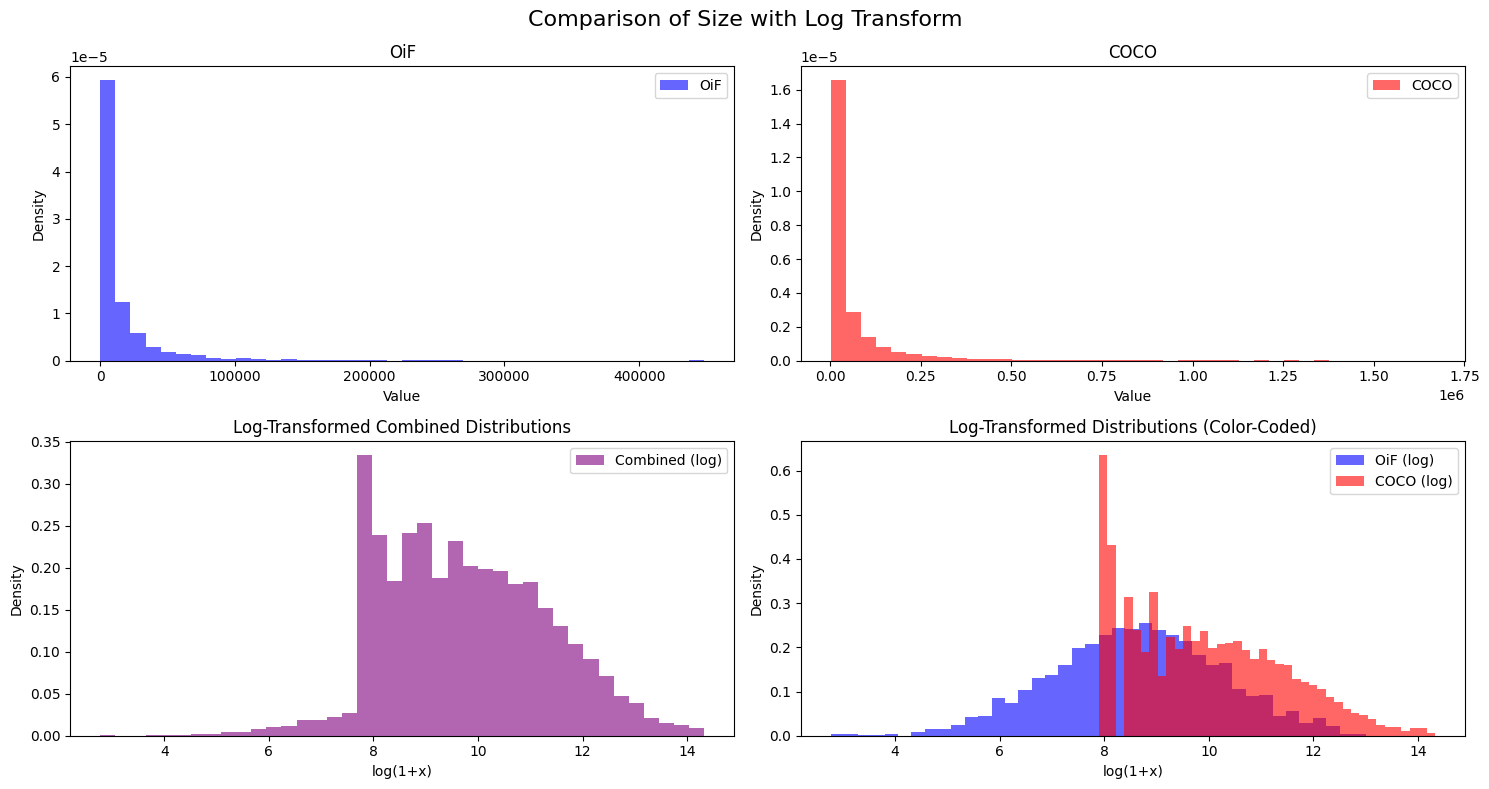

In [ ]:
# Example usage
if __name__ == "__main__":

    # Plot the distributions
    fig, axes, data = plot_distributions_log(
       oif['size'],
       coco['size'],
        bins=40,
        labels=("OiF", "COCO"),
        colors=("blue", "red"),
        combined_color="purple",
        title="Comparison of Size with Log Transform",
        save_path='size.png'  # Change to a path if you want to save the figure
    )

    plt.show()

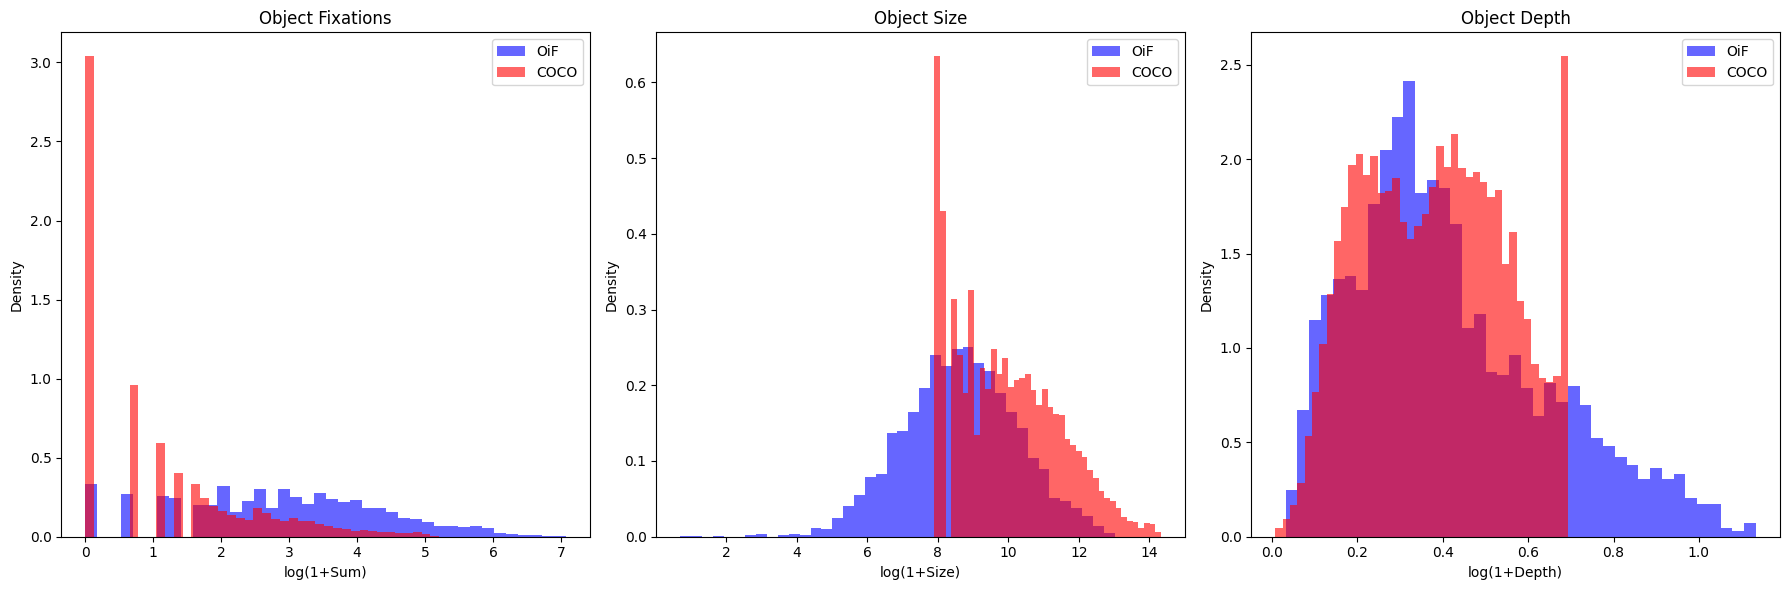

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_combined_log_transforms(oif, coco, bins=40, colors=("blue", "red"), alpha=0.6, figsize=(15, 5)):
    """
    Plot the log-transformed distributions (color-coded) from sum, size, and depth in a side-by-side layout.

    Args:
    oif, coco : pd.DataFrame
        DataFrames containing the data for the OiF and COCO datasets respectively.
    bins : int
        Number of histogram bins.
    colors : Tuple[str, str]
        Colors for the two distributions.
    alpha : float
        Transparency level for histograms (0 to 1).
    figsize : Tuple[int, int]
        Size of the figure (width, height).
    """
    # Log-transform the data
    log_data_oif_sum = np.log1p(oif['sum'])
    log_data_coco_sum = np.log1p(coco['sum'])

    log_data_oif_size = np.log1p(oif['size'])
    log_data_coco_size = np.log1p(coco['size'])

    log_data_oif_depth = np.log1p(oif['depth_center'])
    log_data_coco_depth = np.log1p(coco['depth_center'])

    # Create 1x3 grid for the subplots (side by side)
    fig, axes = plt.subplots(1, 3, figsize=figsize)


    # Plot for 'sum'
    axes[0].hist(log_data_oif_sum, bins=bins, color=colors[0], alpha=alpha, density=True, label="OiF")
    axes[0].hist(log_data_coco_sum, bins=bins, color=colors[1], alpha=alpha, density=True, label="COCO")
    axes[0].set_title("Object Fixations")
    axes[0].set_xlabel("log(1+Sum)")
    axes[0].set_ylabel("Density")
    axes[0].legend()

    # Plot for 'size'
    axes[1].hist(log_data_oif_size, bins=bins, color=colors[0], alpha=alpha, density=True, label="OiF")
    axes[1].hist(log_data_coco_size, bins=bins, color=colors[1], alpha=alpha, density=True, label="COCO")
    axes[1].set_title("Object Size")
    axes[1].set_xlabel("log(1+Size)")
    axes[1].set_ylabel("Density")
    axes[1].legend()

    # Plot for 'depth'
    axes[2].hist(log_data_oif_depth, bins=bins, color=colors[0], alpha=alpha, density=True, label="OiF")
    axes[2].hist(log_data_coco_depth, bins=bins, color=colors[1], alpha=alpha, density=True, label="COCO")
    axes[2].set_title("Object Depth")
    axes[2].set_xlabel("log(1+Depth)")
    axes[2].set_ylabel("Density")
    axes[2].legend()


    # Adjust layout and save the figure
    plt.tight_layout()
    save_path = "log.png"
    plt.savefig(save_path, dpi=1000, bbox_inches='tight')
    plt.show()  # Ensure plot renders before saving
    plt.close(fig)  # Close the figure to free memory

    # Download the figure (only for Google Colab environment)
    try:
        from google.colab import files
        files.download(save_path)
    except ImportError:
        print("Download functionality not available outside of Google Colab.")

# Example usage
plot_combined_log_transforms(oif, coco, bins=40, colors=("blue", "red"), alpha=0.6, figsize=(18, 6))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

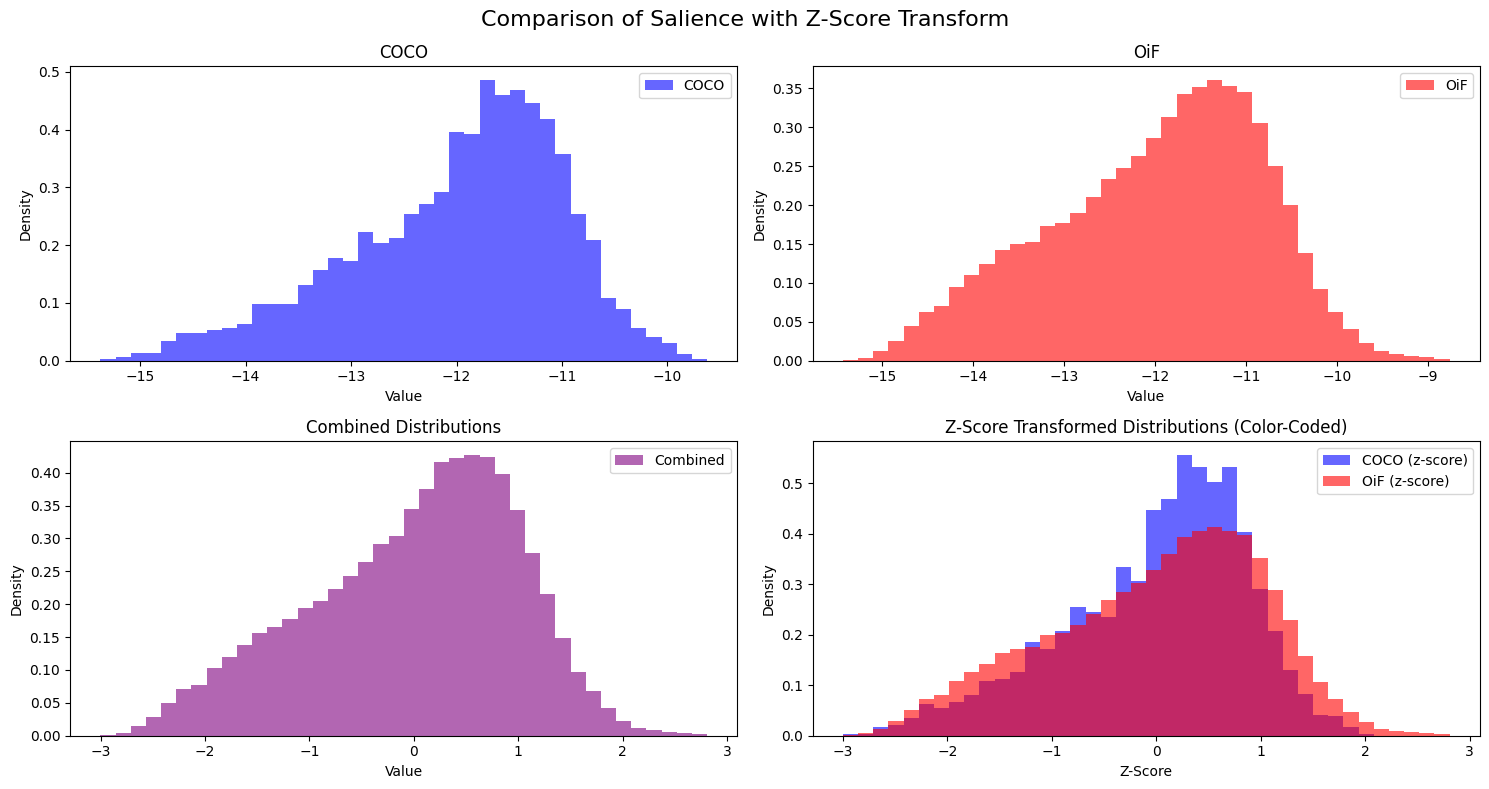

In [ ]:
# Example usage
if __name__ == "__main__":

    # Plot the distributions
    fig, axes, data = plot_distributions_z(
               oif['dg_center'],
       coco['dg_center'],
        bins=40,
        labels=("COCO", "OiF"),
        colors=("blue", "red"),
        combined_color="purple",
        title="Comparison of Salience with Z-Score Transform",
        save_path='salience.png',
    )

    plt.show()

In [ ]:
value_list = ['sum', 'size', 'ecc', 'dg_center', 'depth_center']
datasets = [coco, oif]

for dataset in datasets:
    if dataset is coco:
        print('coco')
    elif dataset is oif:
        print('oif')

    for value_name in value_list:
        print(value_name, end=' ')
        print('mean:', round(dataset[value_name].mean(), 1), end=' ')
        print('std:', round(dataset[value_name].std(), 1), end=' ')
        print('min:', round(dataset[value_name].min(), 1), end=' ')
        print('max:', round(dataset[value_name].max(), 1))

coco
sum mean: 7.6 std: 18.1 min: 0.0 max: 182.0
size mean: 67466.2 std: 148243.2 min: 2700 max: 1668600
ecc mean: 460.3 std: 197.1 min: 1.4 max: 947.9
dg_center mean: -12.0 std: 1.2 min: -15.4 max: -8.8
depth_center mean: 0.5 std: 0.2 min: 0.0 max: 1.0
oif
sum mean: 49.8 std: 96.4 min: 0.0 max: 1180.0
size mean: 18161.4 std: 37547.3 min: 15 max: 448260
ecc mean: 300.5 std: 132.7 min: 8.1 max: 615.9
dg_center mean: -12.0 std: 1.0 min: -15.4 max: -9.6
depth_center mean: 0.6 std: 0.4 min: 0.0 max: 2.1


                            OLS Regression Results                            
Dep. Variable:                log_sum   R-squared:                       0.665
Model:                            OLS   Adj. R-squared:                  0.665
Method:                 Least Squares   F-statistic:                 1.543e+04
Date:                Mon, 01 Sep 2025   Prob (F-statistic):               0.00
Time:                        21:50:46   Log-Likelihood:                -34331.
No. Observations:               31138   AIC:                         6.867e+04
Df Residuals:                   31133   BIC:                         6.871e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.7519      0.029   -128.620      0.0

In [ ]:
coco_best_images

,image,abs_diff
1847,573448,0.384941
617,191540,0.521962
1030,324894,1.567457
1791,558092,1.663912
68,24231,1.822085
1264,400347,2.041146
1760,547156,2.694032
1486,464602,3.378281
1119,350860,3.777179
24,7944,3.786099


In [ ]:
values = oif

values['log_size'] = np.log1p(values['size'])
values['log_sum'] = np.log1p(values['sum'])
values['log_depth'] = np.log1p(values['depth_center'])
values['z_ecc'] = zscore(values['ecc'])
values['z_dg'] = zscore(values['dg_center'])
mod = smf.ols(formula='log_sum ~ log_depth + z_ecc + log_size + z_dg', data=values)
res = mod.fit()
print(res.summary())

# Fit the model and get predictions
X = values[['z_ecc', 'log_size', 'log_depth', 'z_dg']]
y = values['log_sum']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Calculate residuals
residuals = y - y_pred
values['pred'] = y_pred
values['pred_sum'] = np.expm1(values['pred'])
values['residual'] = np.abs(values['log_sum'] - values['pred'])
values['sum_diff'] = values['sum'] - values['pred_sum']
values['abs_diff'] = np.abs(values['sum_diff'])
image_values = values.groupby(['image'])['abs_diff'].sum().reset_index()
coco_best_images = image_values.sort_values(by='abs_diff')[:15]
coco_worst_images = image_values.sort_values(by='abs_diff')[-15:]

                            OLS Regression Results                            
Dep. Variable:                log_sum   R-squared:                       0.804
Model:                            OLS   Adj. R-squared:                  0.803
Method:                 Least Squares   F-statistic:                     5093.
Date:                Fri, 07 Mar 2025   Prob (F-statistic):               0.00
Time:                        22:26:12   Log-Likelihood:                -5027.0
No. Observations:                4986   AIC:                         1.006e+04
Df Residuals:                    4981   BIC:                         1.010e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.6490      0.052    -69.573      0.0

In [ ]:
coco.image.unique()

array([374451,  85632, 366527, ..., 297681, 486170, 405882])

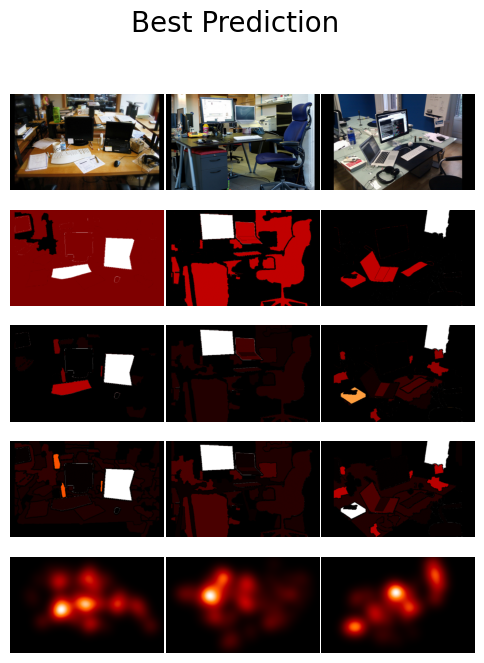

In [ ]:
#best image plot
from PIL import Image

def plot_images_and_heatmaps(images, arrays, figsize=(12, 15), cmap='gist_heat', title_name=''):
    """
    Plot images in the top row and arrays as heatmaps in rows below.
    Arrays are arranged row by row across the grid.

    Parameters:
    -----------
    images : list
        List of 3 images to display in the top row
    arrays : list
        List of 12 numpy arrays to display as heatmaps (4 arrays × 3 rows)
    figsize : tuple, optional
        Figure size (width, height)
    cmap : str, optional
        Colormap to use for heatmaps

    Returns:
    --------
    fig : matplotlib figure
        The created figure object
    """
    if len(images) != 3:
        raise ValueError("Expected 3 images")
    if len(arrays) != 12:
        raise ValueError("Expected 12 arrays for heatmaps")

    # Create figure with 3 columns and 5 rows (1 row for images + 4 rows for heatmaps)
    fig, axes = plt.subplots(5, 3, figsize=figsize)

    # Plot images in the top row
    for i, img in enumerate(images):
        axes[0, i].imshow(img)
        axes[0, i].axis('off')

    # Plot heatmaps in the rows below, arranged row by row
    array_idx = 0
    for row in range(1, 5):  # Rows 1-4 for heatmaps
        for col in range(3):  # 3 columns
            if array_idx < len(arrays):
                axes[row, col].imshow(arrays[array_idx], cmap=cmap)
                axes[row, col].axis('off')
                array_idx += 1

    # Reduce white space
    fig.suptitle(title_name, fontsize=20)
    plt.subplots_adjust(wspace=0.01, hspace=0.01)

    return fig

def load_numpy_arrays(file_paths):
    """
    Takes a list of file paths to numpy arrays and returns a list of the loaded arrays.

    Parameters:
    file_paths (list of str): A list of file paths to numpy arrays.

    Returns:
    list of numpy.ndarray: A list containing the loaded numpy arrays.
    """

    loaded_arrays = [bethonio_gaussian(np.load(file)) for file in file_paths]
    return loaded_arrays

def load_images(image_paths):
    images = []
    for path in image_paths:
        try:
            img = Image.open(path)
            images.append(img)
        except Exception as e:
            print(f"Could not load image at {path}: {e}")
    return images

def list_files(path):
    """Lists all files in the specified directory."""

    files = []
    for entry in os.listdir(path):
        if os.path.isfile(os.path.join(path, entry)):
            files.append(entry[:-4])
    return files

img_dir = 'ms-coco/coco-images/'
mask_dir = 'ms-coco/object_arrays/'
attention_dir = 'ms-coco/fixations/'

best_im = [ '000000081074', '000000399164', '000000326210']

image_paths = [img_dir + item + '.jpg' for item in best_im]
values_paths = [attention_dir + item + '.npy' for item in best_im]

attention_list = load_numpy_arrays(values_paths)
images_list = load_images(image_paths)


pred_list = []
for image in best_im:

  masks = np.load(str(mask_dir + image + '.npy'))
  mask_ids = list(values[values['image']==int(image.lstrip('0'))]['id'])
  image_values = list(values[values['image']==int(image.lstrip('0'))]['pred'])

  pred_list.append(fill_masks_with_values(masks, mask_ids, image_values))

true_list = []
for image in best_im:

  masks = np.load(str(mask_dir + image + '.npy'))
  mask_ids = list(values[values['image']==int(image.lstrip('0'))]['id'])
  image_values = list(values[values['image']==int(image.lstrip('0'))]['sum'])

  true_list.append(fill_masks_with_values(masks, mask_ids, image_values))

res_list = []
for image in best_im:

  masks = np.load(str(mask_dir + image + '.npy'))
  mask_ids = list(values[values['image']==int(image.lstrip('0'))]['id'])
  image_values = list(values[values['image']==int(image.lstrip('0'))]['abs_diff'])

  res_list.append(fill_masks_with_values(masks, mask_ids, image_values))

arrays_list = pred_list + true_list + res_list + attention_list

fig = plot_images_and_heatmaps(images_list, arrays_list, figsize=(6, 7.5), cmap='gist_heat', title_name = 'Best Prediction')
#plt.savefig("figures/best_examples.png", dpi=1000)
#files.download("figures/best_examples.png")


In [ ]:
values.groupby('image')['id'].count().sort_values(ascending=False)


,id
image,
81074,41
340155,36
367725,30
326210,29
399164,28
...,...
485481,1
434502,1
92050,1


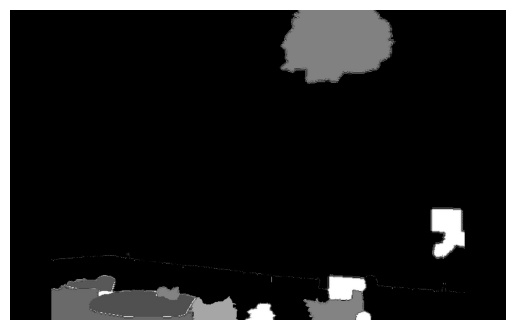

In [ ]:
image = '377583'
import cv2
masks = np.load('ms-coco/modified_numpy_arrays/000000234161.npy')
mask_ids = list(values[values['image']==234161]['id'])
values['pred'] = values['pred'].astype(int)
image_values = list(values[values['image']==234161]['pred'])
img_array = masks
# Ensure the array is in the correct format (H, W, C)
if img_array.ndim == 2:  # If grayscale, convert to RGB
    img_array = cv2.cvtColor(img_array, cv2.COLOR_GRAY2RGB)
elif img_array.shape[-1] == 3:  # If already RGB/BGR, check for proper format
    img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(img_array, cmap='gist_heat')
plt.axis('off')  # Hide axis
plt.show()

In [ ]:
masks.shape

(1050, 1680, 3)

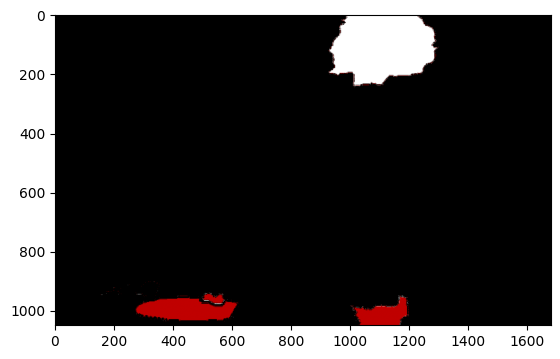

In [ ]:
plt.imshow(fill_masks_with_values(masks, mask_ids, image_values), cmap='gist_heat')

In [ ]:
 ['000000377583', '000000002024', '000000125755', '000000260519', '000000141278',  '000000486114']

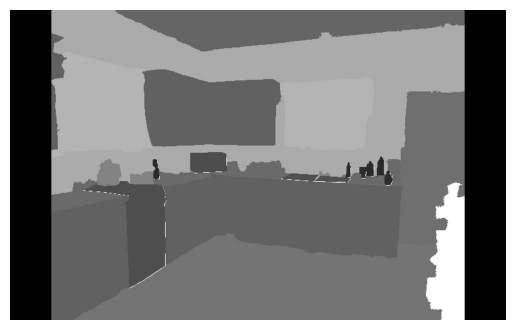

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load .npy file correctly
img_array = np.load('ms-coco/object_arrays/000000377583.npy')

# Ensure the array is in the correct format (H, W, C)
if img_array.ndim == 2:  # If grayscale, convert to RGB
    img_array = cv2.cvtColor(img_array, cv2.COLOR_GRAY2RGB)
elif img_array.shape[-1] == 3:  # If already RGB/BGR, check for proper format
    img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(img_array)
plt.axis('off')  # Hide axis
plt.show()


In [ ]:
values[values['image']==573448]

,image,label,sum,size,ecc,id,log_size,log_sum,depth,centroid_x,...,log_depth,z_ecc,z_dg,pred,pred_sum,residual,sum_diff,abs_diff,summed_count_total,proportion
12804,573448,bowl,13.0,58500,424.697539,50,10.976799,2.639057,0.635053,1052,...,0.451134,-0.175528,1.495825,2.611176,12.615059,0.027881,0.384941,0.384941,13.0,1.0


In [ ]:
str(mask_dir + image + '.npy')

'ms-coco/modified_numpy_arrays/000000324894.npy'

In [ ]:
import math
def bethonio_gaussian(img, fc=6):
    """Gaussian low-pass filter with circular boundary conditions.
         Adapted from MATLAB function by Antonio Torralba (1999).
         See https://github.com/cvzoya/saliency/blob/master/code_forMetrics/antonioGaussian.m

    Parameters
    ----------
    img = input image
    fc = cut-off frequency (-6dB)
    gf = gaussian filter

    Returns
    -------
    BF = filtered image

    NOTE: If the image is not square, there may be some boundary artifacts
    do to zero padding.
    """

    # check if array has a color channel
    if img.ndim > 2:
        sn, sm, c = img.shape

    else:
        sn, sm = img.shape
        c = 0

    n = np.amax([sn, sm])
    n= n + np.remainder(n,2)
    n = 2**(math.ceil(math.log2(n)))

    # make frequencies
    [fx, fy] = np.mgrid[0:n, 0:n]
    fx=fx-n/2
    fy=fy-n/2

    #convert cut off frequency into gaussian width:
    sigma=fc/math.sqrt(math.log(2))

    #compute transfer function of gaussian filter:
    gf = np.exp(-(np.power(fx,2) + np.power(fy, 2))/(sigma**2))
    gf = np.fft.fftshift(gf)

    # convolve (in fourier domain) each color band:
    if c > 0:
        BF = np.zeros((n, n, c))

        for i in range(c):
            BF[:,:,i] = np.fft.ifft2(
                    np.fft.fft2(
                        img[:, :, i], s=(n, n))*gf).real
        BF = BF[0:sn, 0:sm, :]

    # if no color channel
    else:
        BF = np.zeros((n, n))
        BF[:,:] = np.fft.ifft2(
                np.fft.fft2(
                    img[:, :], s=(n, n))*gf).real
        BF = BF[0:sn, 0:sm]

    return BF


def fill_masks_with_values(masks, mask_ids, values):
    """
    Fill each mask with its corresponding value based on mask IDs.

    Parameters:
    -----------
    masks : numpy.ndarray
        Array of mask labels, shape (H, W) or (H, W, C)
    mask_ids : list or numpy.ndarray
        List of mask IDs to fill
    values : list or numpy.ndarray
        List of values to fill the masks with

    Returns:
    --------
    numpy.ndarray
        Array with same shape as input masks, with regions filled according to values

    Example:
    --------
    >>> masks = np.array([[1, 1, 0], [2, 0, 2], [0, 2, 1]])
    >>> mask_ids = [1, 2]
    >>> values = [10, 20]
    >>> fill_masks_with_values(masks, mask_ids, values)
    array([[10, 10,  0],
           [20,  0, 20],
           [ 0, 20, 10]])
    """
    if len(mask_ids) != len(values):
        raise ValueError("Length of mask_ids must match length of values")
          # Load image mask

    img_array = masks
    if img_array.ndim == 3 and img_array.shape[-1] == 3:
        img_array = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    elif img_array.ndim > 2:
        raise ValueError(f"Array in {image} has too many dimensions: {img_array.ndim}")

                # Normalize if needed
    if img_array.dtype in [np.float32, np.float64] and img_array.max() <= 1.0:
        img_array = (img_array * 255).astype(np.uint8)
    # Convert inputs to numpy arrays if they aren't already
    masks = img_array
    masks = np.asarray(masks)
    mask_ids = np.asarray(mask_ids)
    values = np.asarray(values)

    # Create output array filled with zeros
    result = np.zeros_like(masks, dtype=float)

    # Fill each mask with its corresponding value
    for mask_id, value in zip(mask_ids, values):
        result[masks == mask_id] = value

    return result

In [ ]:
num_objects = coco.groupby('image').count().reset_index()
print('coco num objects:', num_objects['sum'].mean())
print('coco std objects:', num_objects['sum'].std())
print('coco unique objects:', coco.id.nunique())
print('coco image unique:', coco.image.nunique())
print('coco image unique:', coco[' unique_id'].nunique())

coco num objects: 13.882300490414623
coco std objects: 8.314860124985183
coco unique objects: 128
coco image unique: 2243
coco image unique: 28576


In [ ]:
coco = pd.read_csv('combined_output.csv')
num_objects = coco.groupby('image').count().reset_index()
print('coco num objects:', num_objects['sum'].mean())
print('coco std objects:', num_objects['sum'].std())
print('coco unique objects:', coco.id.nunique())
print('coco image unique:', coco.image.nunique())
print('coco image unique:', coco[' unique_id'].nunique())

coco num objects: 9.472980203317283
coco std objects: 4.744651305055757
coco unique objects: 118
coco image unique: 1869
coco image unique: 17705


In [ ]:
num_objects = oif_mem.groupby('image').count().reset_index()
print('oif avg objects:', num_objects['sum'].mean())
print('oif std objects:', num_objects['sum'].std())
print('oif unique obs:', oif_aes.label.nunique())
print('oif unique ims:', oif_aes.image.nunique())
print('oif total objs:', oif_aes.id.nunique())

oif avg objects: 24.96
oif std objects: 12.861280078301899
oif unique obs: 360
oif unique ims: 100
oif total objs: 2496


In [ ]:
coco2[:50]

,image,label,sum,size,ecc,id,log_size,log_sum,centroid_x,centroid_y,...,num_cluster,unique_id,log_depth,z_ecc,z_dg,pred,pred_sum,residual,sum_diff,abs_diff
0,36567,cabinet,7.0,356400,392.947834,97,12.783812,2.079442,1002,167,...,0,000000036567cabinet0,0.161814,-0.344337,-0.307760,2.520077,11.429557,0.440636,-4.429557,4.429557
1,36567,cabinet,5.0,67500,153.394915,97,11.119898,1.791759,813,676,...,1,000000036567cabinet1,0.285950,-1.560698,0.346511,2.207240,8.090590,0.415480,-3.090590,3.090590
2,36567,refrigerator,36.0,196200,314.377162,81,12.186895,3.610918,532,588,...,0,000000036567refrigerator0,0.355805,-0.743289,0.313521,2.579081,12.185018,1.031837,23.814982,23.814982
3,36567,counter,5.0,173700,572.763476,106,12.065091,1.791759,1313,848,...,0,000000036567counter0,0.332226,0.568701,0.512629,2.405058,10.079074,0.613299,-5.079074,5.079074
4,36567,counter,4.0,10800,52.172790,106,9.287394,1.609438,789,514,...,1,000000036567counter1,0.271010,-2.074666,0.807798,1.613415,4.019927,0.003977,-0.019927,0.019927
5,36567,oven,36.0,107100,252.926867,78,11.581528,3.610918,1074,621,...,0,000000036567oven0,0.283423,-1.055311,0.872154,2.623387,12.782323,0.987531,23.217677,23.217677
6,36567,microwave,8.0,37800,351.808186,77,10.540091,2.197225,1100,288,...,0,000000036567microwave0,0.116666,-0.553229,0.954578,2.083411,7.031821,0.113813,0.968179,0.968179
7,36567,cup,0.0,18900,650.120758,46,9.846970,0.000000,1484,614,...,0,000000036567cup0,0.260257,0.961492,0.403276,1.183471,2.265691,1.183471,-2.265691,2.265691
8,36567,sink,2.0,4500,545.883687,80,8.412055,1.098612,1382,590,...,0,000000036567sink0,0.163691,0.432215,1.123525,0.934620,1.546245,0.163992,0.453755,0.453755
9,36567,chair,0.0,5400,731.882504,61,8.594339,0.000000,274,989,...,0,000000036567chair0,0.474491,1.376648,-1.662663,-0.597738,-0.449946,0.597738,0.449946,0.449946


In [ ]:
values = oif_aes

values['log_size'] = np.log1p(values['size'])
values['log_sum'] = np.log1p(values['sum'])
values['log_depth'] = np.log1p(values['depth_center'])
values['z_ecc'] = zscore(values['ecc'])
values['z_dg'] = zscore(values['dg_center'])
mod = smf.ols(formula='log_sum ~ log_depth + z_ecc + log_size + z_dg', data=values)
res = mod.fit()
print(res.summary())

# Fit the model and get predictions
X = values[['z_ecc', 'log_size', 'log_depth', 'z_dg']]
y = values['log_sum']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Calculate residuals
residuals = y - y_pred
values['pred'] = y_pred
values['pred_sum'] = np.expm1(values['pred'])
values['residual'] = np.abs(values['log_sum'] - values['pred'])
values['sum_diff'] = values['sum'] - values['pred_sum']
values['abs_diff'] = np.abs(values['sum_diff'])
image_values = values.groupby(['image'])['abs_diff'].sum().reset_index()
best_images = image_values.sort_values(by='abs_diff')[:15]
worst_images = image_values.sort_values(by='abs_diff')[-15:]

                            OLS Regression Results                            
Dep. Variable:                log_sum   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     2532.
Date:                Thu, 06 Mar 2025   Prob (F-statistic):               0.00
Time:                        02:14:43   Log-Likelihood:                -2556.0
No. Observations:                2496   AIC:                             5122.
Df Residuals:                    2491   BIC:                             5151.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.5431      0.074    -47.559      0.0

In [ ]:
values = oif_mem

values['log_size'] = np.log1p(values['size'])
values['log_sum'] = np.log1p(values['sum'])
values['log_depth'] = np.log1p(values['depth_center'])
values['z_ecc'] = zscore(values['ecc'])
values['z_dg'] = zscore(values['dg_center'])
mod = smf.ols(formula='log_sum ~ log_depth + z_ecc + log_size + z_dg', data=values)
res = mod.fit()
print(res.summary())

# Fit the model and get predictions
X = values[['z_ecc', 'log_size', 'log_depth', 'z_dg']]
y = values['log_sum']
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Calculate residuals
residuals = y - y_pred
values['pred'] = y_pred
values['pred_sum'] = np.expm1(values['pred'])
values['residual'] = np.abs(values['log_sum'] - values['pred'])
values['sum_diff'] = values['sum'] - values['pred_sum']
values['abs_diff'] = np.abs(values['sum_diff'])
image_values = values.groupby(['image'])['abs_diff'].sum().reset_index()
best_images = image_values.sort_values(by='abs_diff')[:15]
worst_images = image_values.sort_values(by='abs_diff')[-15:]

                            OLS Regression Results                            
Dep. Variable:                log_sum   R-squared:                       0.802
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     2520.
Date:                Thu, 06 Mar 2025   Prob (F-statistic):               0.00
Time:                        02:26:21   Log-Likelihood:                -2500.9
No. Observations:                2496   AIC:                             5012.
Df Residuals:                    2491   BIC:                             5041.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.6003      0.073    -49.405      0.0

<Axes: xlabel='image', ylabel='abs_diff'>

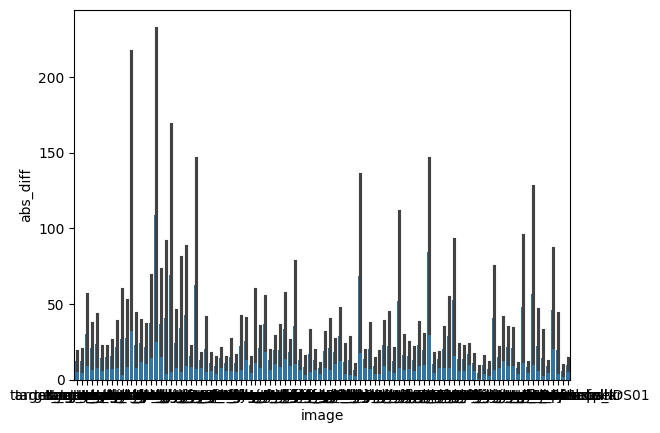

In [ ]:
import seaborn as sns
sns.barplot(x = 'image', y = 'abs_diff', data = values)

In [ ]:
import glob
import os
import pandas as pd

def combine_csv_files(folder_path, output_file='combined_output3.csv'):
    """
    Combines all CSV files in the specified folder into one CSV file.

    Parameters:
    folder_path (str): Path to the folder containing CSV files
    output_file (str): Name of the output file

    Returns:
    bool: True if successful, False otherwise
    """
    try:
        # Get all CSV files in the folder
        csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

        if not csv_files:
            print(f"No CSV files found in {folder_path}")
            return False

        # Create an empty list to store individual dataframes
        dfs = []

        # Read each CSV file and append to the list
        for file in csv_files:
            df = pd.read_csv(file)
            dfs.append(df)
            print(f"Processed: {file}")

        # Combine all dataframes into one
        combined_df = pd.concat(dfs, ignore_index=True)

        # Write the combined dataframe to a new CSV file
        combined_df.to_csv(output_file, index=False)

        print(f"Successfully combined {len(csv_files)} CSV files into {output_file}")
        return True

    except Exception as e:
        print(f"Error: {e}")
        return False

# Example usage
if __name__ == "__main__":
    # Replace with your folder path
    folder_path = "./ms-coco/coco-results3"
    combine_csv_files(folder_path)

In [ ]:
def generate_density_map(folder_path, width=1680, height=1050):
    # Initialize the density map with zeros
    density_map = np.zeros((height, width), dtype=np.float32)

    # Loop through all .npy files in the given folder
    for filename in os.listdir(folder_path):
        if filename.endswith('.npy'):
            # Load the .npy array
            file_path = os.path.join(folder_path, filename)
            obj_array = np.load(file_path)

            # If the array has 3 channels, convert it to grayscale (use the first channel or average)
            if obj_array.ndim == 3:
                obj_array = obj_array[:, :, 0]  # Take the first channel (R channel for RGB)
                # Alternatively, you could average the channels if needed:
                # obj_array = np.mean(obj_array, axis=-1)

            # Loop through unique values in the array
            for unique_value in np.unique(obj_array):
                # Create a binary mask for the current unique value
                binary_mask = (obj_array == unique_value).astype(np.float32)

                # Add the binary mask to the density map
                density_map += binary_mask

    # Optionally, normalize the density map if needed (e.g., scale the values)
    density_map = np.clip(density_map, 0, 1)  # Keep values between 0 and 1

    # Plot the final density map
    plt.imshow(density_map, cmap='gist_heat', interpolation='nearest')
    plt.colorbar(label='Density')
    plt.title('Density Map')


    plt.tight_layout()
    #plt.show()
    #plt.show()

    # Save the figure as 'MAE.png' with dpi 500
    plt.savefig('coco-ob.png', dpi=800, bbox_inches='tight')


    # Download the figure (only for Google Colab environment)
    try:
        from google.colab import files
        files.download('coco-ob.png')
    except ImportError:
        print("Download functionality not available outside of Google Colab.")
    return density_map

# Example usage:
folder_path =  'ms-coco/modified_numpy_arrays/'
density_map = generate_density_map(folder_path)
